# Full Method 1 Notebook — Warmup End-to-End (E2E) Training
## KG-GT with Joint Transformer + GAT Optimization
**Training Mode**: Supports both **Single-Subject (Per Subject)** and **Leave-One-Subject-Out Cross-Validation (LOSOCV)**.

### Pipeline Strategy:
- **Phase 1 (Warmup)**: Freeze Transformer backbone & node projection. Train GAT encoder, Decoder, and Kinematic Skip Highway with initial learning rate ($1 \times 10^{-4}$) to align the graph topology with kinematics.
- **Phase 2 (Joint E2E Finetuning)**: Unfreeze all parameters. Jointly optimize the Transformer backbone, GAT, and Kinematic Skip Highway with a differential learning rate multiplier (`transformer_lr_scale = 0.05` for Transformer, base LR for GAT/Decoder).

In [25]:
import torch
import numpy as np
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from pathlib import Path
import os, gc, time, copy
import pandas as pd

ROOT = Path(".")
from main import (
    get_device, set_seed,
    load_hs,
    preprocess_eeg_from_config,
    preprocess_emg_from_config,
    preprocess_kinematics_from_config,
    compute_muscle_edge_prior,
    WAYEEGDataset, resolve_participants, ALL_PARTICIPANTS,
    build_kg_gt_from_config,
    build_loss_from_config,
    train_model, TrainConfig,
    collect_predictions, compute_metrics,
    load_checkpoint, save_checkpoint,
    plot_training_history,
    plot_interpretability_triptych,
    plot_muscle_synergy_matrix,
    plot_kin_edge_linear_weights,
    plot_neural_mechanical_latency_lag,
    plot_spectral_power_decomposition,
    plot_kinematic_velocity_acceleration_density,
)

In [26]:
set_seed(42)
device = get_device()
torch.backends.cudnn.benchmark = True
print(f"Device: {device}")

Device: cuda


In [27]:
CONFIG = {
    "outputs":{
        "figures_dir": "docs/figure/method1",
    },
    "data": {
        "participant": "P1",       
        "data_root": "data/way-eeg/raw",
        "cache_dir": "data/cache_main_stride500",
        # window_size=4000 @ 500 Hz = 8 s window; stride=250 = 0.5 s step
        # chunked transformer: 4000 / chunk_size=500 = 8 chunks of 500 → O(500²) not O(4000²)
        "window_size": 500,
        "stride": 500,
        "latency_shift_ms": 50.0,
        "fs_eeg": 500,                   # Hz
        "fs_emg": 4000,                  # Hz (raw); downsampled to fs_eeg after preprocess
        "fs_kin": 500,                   # Hz
        "n_eeg_channels": 32,
        "n_emg_channels": 5,
        "n_kin_raw": 36,                 # raw kin cols in hs.kin.sig
        "n_kin_features": 36             # k_t dimension after extraction
    },
    "preprocessing": {
        "eeg": {
            "bp_low": 0.5,                  # Hz, bandpass lower bound
            "bp_high": 40.0,                # Hz, bandpass upper bound
            "artifact_method": "ica_auto",  # "asr" | "ica_auto" | "ica_manual"
            "filter_order": 4,
            "notch_freq": 50.0,             # Hz, power-line
            "asr_window_ms": 500,           # ms, ASR sliding window
            "asr_std_thresh": 5.0,          # sigma, ASR rejection threshold
            "delta_low": 0.5,               # Hz, delta-band lower bound
            "delta_high": 40.0,             # Hz, delta-band upper bound
            "use_car": False,
            "use_tkeo": True,
            #"target_channels": ["FC1", "FC2", "C3", "Cz", "C4", "CP1", "CP2", "CP6"]
        },
        "emg": {
            "bp_low": 30.0,              # Hz
            "bp_high": 300.0,            # Hz
            "filter_order": 4,
            "lp_cutoff": 8.0,           # Hz, low-pass for envelope
            "downsample_factor": 8       # 4000 -> 500 Hz
        },
        "kinematics": {
            "include_velocity": True,      # if true, output includes velocity
            "include_acceleration": True,  # if true, output includes acceleration
            "drop_indices": [12, 25, 38],  # prune rho_GL from pos, vel, acc
            "velocity_method": "sg",     # 'sg' (Savitzky-Golay) | 'bw' (Butterworth diff)
            "sg_window": 11,             # SG window length (samples, must be odd)
            "sg_poly": 3,                # SG polynomial order
            "bw_cutoff": 20.0,           # LP cutoff Hz before diff (used when method='bw')
            "bw_order": 4,               # Butterworth order (used when method='bw')
            "normalize": True            # per-feature z-score over training set
        },
    },
    "model": {
        "type": "transformer_regressor",
        "transformer": {
            "n_layers": 4,
            "n_heads": 8,
            "d_model": 128,
            "d_k": 32,
            "d_v": 32,
            "ffn_dim": 512,
            "dropout": 0.2,
            # chunk_size=500 with window_size=4000 → 8 chunks of 500
            # → O(500²)=250K scores per head (not O(4000²)=16M)
            # MUST divide window_size evenly or a RuntimeWarning fires and
            # full O(T²) attention is used (catastrophically slow).
            "chunk_size": 500
        },
        "gat": {
            "n_layers": 2,
            "node_dim": 64,
            "hidden_dim": 64,
            "heads": 4,
            "dropout": 0.2,
            "use_kinematic_guidance": True,
        },
        "decoder": {
            "out_channels": 5            # predicted EMG channels
        }
    },
    "training": {
        "loss": {
            "peak_alpha":      5.0,    # 3× emphasis on EMG burst peaks vs. baseline silence
            "lambda_reg":      0.001,   # KL anchor strength: GAT edge_bias stays near prior
            "lambda_l1": 0.05,
            "lambda_grad":     0.2,
            "rest_threshold":  0.15,
            "asymmetry": 2.5,
            "use_peak_weight": True,   # set False for ablation back to standard MSE
        },
        # ── optimizer ─────────────────────────────────────────────────────
        "optimizer":   "adamw",   # 'adam' | 'adamw'
        "weight_decay": 0.05,# AdamW weight decay (ignored for adam)
        # ── scheduler ─────────────────────────────────────────────────────
        "scheduler":   "cosine",  # 'reduce' | 'cosine'
        # reduce-specific
        "lr_patience": 5,
        "lr_factor":   0.05,
        # cosine-specific
        "cosine_t_max":   None,   # None → use max_epochs
        "cosine_eta_min": 1e-6,
        # ── common ────────────────────────────────────────────────────────
        "loss_lambda":  1.0,      # 1.0 = plain MSE; <1.0 enables Soft-DTW (O(T²), DO NOT use at T=4000)
        "stage1_lr": 5e-3,
        "stage2_lr": 1e-5,
        # batch_size=4 with T=4000 keeps VRAM safe on GTX 1660 Ti (6 GB).
        # effective batch = batch_size * gradient_accumulation_steps = 4 * 8 = 32
        # Tune batch_size up (e.g. 8) if VRAM is available; reduce grad_accum_steps proportionally.
        "batch_size":          32,
        "gradient_accumulation_steps": 2,
        "early_stop_patience": 50,
        "grad_clip_norm":      1.0,
        "stage1_epochs":       75,
        "max_epochs":          200,
        # use_amp=True: enables FP16 mixed precision via torch.autocast + GradScaler.
        # GTX 1660 Ti (sm_75 Turing) has FP16 tensor cores → ~1.5-2x speedup.
        # Requires PyTorch >= 2.0. Set False only if you see NaN losses.
        "use_amp":             True,
        "log_memory_every":    50,
        "losocv": True,           # leave-one-subject-out cross-validation
        "checkpoint_every":     1,
        "seed":                42,
    },
    "dataset": {
        # Keep in sync with data.window_size / data.stride above
        "window_size": 500,
        "stride": 500,
        "latency_shift_ms": 50.0,
    }
}
notebook_cfg = copy.deepcopy(CONFIG)

In [28]:
def make_preprocess_fn(cfg):
    eeg_cfg = cfg["preprocessing"]["eeg"]
    emg_cfg = cfg["preprocessing"]["emg"]
    kin_cfg = cfg["preprocessing"]["kinematics"]
    def preprocess_fn(series):
        series = dict(series)
        series["eeg"] = preprocess_eeg_from_config(
            series["eeg"],
            float(series["fs_eeg"]),
            eeg_cfg,
            channel_names=series.get("eeg_names"),
        )
        series["emg"] = preprocess_emg_from_config(
            series["emg"],
            float(series["fs_emg"]),
            emg_cfg,
        )
        series["kin"] = preprocess_kinematics_from_config(                                           
              series["kin"],                                                                           
              float(series["fs_kin"]),                                                                 
              kin_cfg,                                                                                 
        ) 
        return series

    return preprocess_fn


def resolve_participants(participant_spec):
    """Resolve participant spec to a list of int IDs.
    
    Accepts:
      "all"        -> [1, 2, ..., 12]
      "P3"         -> [3]
      3            -> [3]
      [1, 2, 3]   -> [1, 2, 3]
      ["P1", "P3"] -> [1, 3]
    """
    ALL_PARTICIPANTS = list(range(1, 13))
    if participant_spec == "all":
        return ALL_PARTICIPANTS
    if isinstance(participant_spec, (list, tuple)):
        return [int(str(p).replace("P", "")) for p in participant_spec]
    # single string like "P2" or int like 2
    return [int(str(participant_spec).replace("P", ""))]


def build_dataset_split(cfg, participants=None, split="train", root_dir=ROOT):
    """Build WAYEEGDataset for the given split.
    
    participants: list of int IDs, or None (uses cfg["data"]["participant"]).
    split: "train" | "val" | "test" | "all" | "stability"
    """
    data_cfg = cfg["data"]
    if participants is None:
        participants = resolve_participants(data_cfg["participant"])
    return WAYEEGDataset(
        data_dir=root_dir / data_cfg["data_root"],
        participants=participants,
        split=split,
        window_size=cfg["dataset"]["window_size"],
        stride=cfg["dataset"]["stride"],
        latency_shift_ms=cfg["dataset"].get("latency_shift_ms", 0.0),
        preprocess_fn=make_preprocess_fn(cfg),
        cache_dir=root_dir / data_cfg["cache_dir"]
    )

In [29]:
# ============================================================================
# Participant / Experiment Setup & Configuration Override
# ============================================================================
notebook_cfg = copy.deepcopy(CONFIG)

# ── Participant Selection ───────────────────────────────────────────────────
# Supported values for notebook_cfg["data"]["participant"]:
#   "all"      → LOSOCV over all 12 subjects (or list like [1, 3, 5])
#   "P2" or 2  → Single-subject training (uses series train/val/test split)
#
# Set active participant here:
notebook_cfg["data"]["participant"] = "P1"   # e.g., "P2", 2, "all", or [1, 2, 3]
notebook_cfg["training"]["losocv"]  = True   # Ignored if single participant

# ── Warmup E2E Hyperparameters (override here if needed) ─────────────────────
notebook_cfg["training"]["warmup_epochs"]        = 40     # Phase 1 epochs (Transformer frozen)
notebook_cfg["training"]["warmup_lr"]            = 3e-4  # Phase 1 LR (GAT + Decoder + Kin Skip)
notebook_cfg["training"]["e2e_lr"]               = 3e-4  # Phase 2 LR (GAT + Decoder)
notebook_cfg["training"]["transformer_lr_scale"] = 0.1  # Phase 2 Transformer LR scale: e2e_lr * 0.05
notebook_cfg["training"]["max_epochs"]           = 200    # Total budget
notebook_cfg["training"]["early_stop_patience"]  = 30
notebook_cfg["training"]["checkpoint_dir"]       = "outputs/checkpoints_e2e"

# ── Kinematic Dimensions: 39 raw - 3 dropped = 36 ───────────────────────────
notebook_cfg["data"]["n_kin_features"] = 36

# ── Resolve Split / Mode ────────────────────────────────────────────────────
participant_spec = notebook_cfg["data"]["participant"]
participant_list = resolve_participants(participant_spec)
is_losocv = (isinstance(participant_spec, (list, tuple)) or participant_spec == "all") and len(participant_list) > 1 and notebook_cfg["training"].get("losocv", True)

if is_losocv:
    print(f"LOSOCV mode: {len(participant_list)} participants -> {participant_list}")
    # Initialise first fold
    p_test = participant_list[0]
    _train_candidates = [p for p in participant_list if p != p_test]
    val_participant    = _train_candidates[-1]          # held-out training subject for early stopping
    train_participants = _train_candidates[:-1]          # remaining subjects for training
    test_participants  = [p_test]
    split_train = split_val = split_test = "all"
    subject_str = f"LOSO_P{p_test}"
else:
    p_id = participant_list[0]
    train_participants = [p_id]
    val_participant    = p_id          # same subject, different series
    test_participants  = [p_id]
    split_train, split_val, split_test = "train", "val", "test"
    subject_str = f"P{p_id}"

# ── Summary ─────────────────────────────────────────────────────────────────
t = notebook_cfg["training"]
warmup_ep = t["warmup_epochs"]
e2e_ep    = t["max_epochs"] - warmup_ep
print("\n" + "="*60)
print("  WARMUP E2E EXPERIMENT CONFIGURATION")
print("="*60)
print(f"  Active subject string : {subject_str}")
print(f"  Mode                  : {'LOSOCV' if is_losocv else 'Single Subject'}")
print(f"  Train participants    : {train_participants}  ({len(train_participants)} subjects, split={split_train!r})")
print(f"  Val  participant      : [{val_participant}]  (split={split_val!r})")
print(f"  Test participants     : {test_participants}   (split={split_test!r})")
print(f"  Phase 1 (Warmup)      : {warmup_ep} epochs @ lr={t['warmup_lr']:.2e} (Transformer frozen)")
print(f"  Phase 2 (E2E Joint)   : {e2e_ep} epochs @ gat_lr={t['e2e_lr']:.2e}, trans_lr={t['e2e_lr']*t['transformer_lr_scale']:.2e}")
print(f"  Total Budget          : {t['max_epochs']} epochs (Patience: {t['early_stop_patience']})")
print(f"  Kin features          : {notebook_cfg['data']['n_kin_features']}")
print("="*60 + "\n")


  WARMUP E2E EXPERIMENT CONFIGURATION
  Active subject string : P1
  Mode                  : Single Subject
  Train participants    : [1]  (1 subjects, split='train')
  Val  participant      : [1]  (split='val')
  Test participants     : [1]   (split='test')
  Phase 1 (Warmup)      : 40 epochs @ lr=3.00e-04 (Transformer frozen)
  Phase 2 (E2E Joint)   : 160 epochs @ gat_lr=3.00e-04, trans_lr=3.00e-05
  Total Budget          : 200 epochs (Patience: 30)
  Kin features          : 36



In [30]:
# ============================================================================
# [OPTIONAL] Automatic LOSOCV — Warmup E2E Training — All Folds Unattended
# ============================================================================
if not is_losocv:
    print(f"[LOSOCV] Skipped: participant={participant_spec!r} (single-subject mode).")
    print("          Use the cells below to run per-subject training and evaluation step-by-step.")
else:
    import time, gc, os
    import pandas as pd
    from main.dataloader import load_hs
    from main import (
        WAYEEGDataset, resolve_participants,
        build_kg_gt_from_config, build_loss_from_config,
        train_model, TrainConfig,
        collect_predictions, compute_metrics,
        load_checkpoint, compute_muscle_edge_prior
    )

    EMG_NAMES = ["DELT", "BIC", "TRI", "BRA", "FCR"]
    cv_rows   = []
    _t_start  = time.time()

    print("="*65)
    print("  STARTING AUTOMATIC LOSOCV — WARMUP E2E TRAINING")
    print(f"  Participants ({len(participant_list)}): {participant_list}")
    print(f"  Warmup: {warmup_ep} ep @ {notebook_cfg['training']['warmup_lr']:.1e} | E2E: {e2e_ep} ep @ {notebook_cfg['training']['e2e_lr']:.1e} (trans scale: {notebook_cfg['training']['transformer_lr_scale']})")
    print("="*65)

    for _fold_idx, _p_test in enumerate(participant_list):
        _t_fold = time.time()
        _train_cands = [p for p in participant_list if p != _p_test]
        _val_p       = _train_cands[-1]
        _train_ps    = _train_cands[:-1]
        _subj        = f"LOSO_P{_p_test}"

        print(f"\n[{_fold_idx+1}/{len(participant_list)}] {_subj} | Val: P{_val_p} | Train ({len(_train_ps)}): {_train_ps}")

        # ── Datasets ─────────────────────────────────────────────────────────
        _train_ds = build_dataset_split(notebook_cfg, participants=_train_ps, split="all")
        _val_ds   = build_dataset_split(notebook_cfg, participants=[_val_p],   split="all")
        _test_ds  = build_dataset_split(notebook_cfg, participants=[_p_test],  split="all")

        # ── Normalization & Feature Dropping ─────────────────────────────────
        def _get_arrays(ds):
            seen, eegs, kins, emgs = set(), [], [], []
            for e, k, m, _ in ds._windows:
                if id(e) in seen: continue
                seen.add(id(e))
                eegs.append(e); kins.append(k); emgs.append(m)
            return eegs, kins, emgs

        _teegs, _tkins, _temgs = _get_arrays(_train_ds)
        _kin_all = np.concatenate(_tkins, axis=0)
        _emg_all = np.concatenate(_temgs, axis=0)

        _em = torch.tensor(_emg_all.mean(0), dtype=torch.float32, device=device)
        _es = torch.clamp(torch.tensor(_emg_all.std(0),  dtype=torch.float32, device=device), min=1e-6)
        _km = torch.tensor(_kin_all.mean(0), dtype=torch.float32, device=device)
        _ks = torch.clamp(torch.tensor(_kin_all.std(0),  dtype=torch.float32, device=device), min=1e-6)
        _drop = notebook_cfg["preprocessing"]["kinematics"]["drop_indices"]

        def _make_pb(em, es, km, ks, drop):
            def pb(eeg, kin, emg):
                eeg = eeg.to(device, non_blocking=True)
                kin = kin.to(device, non_blocking=True)
                emg = emg.to(device, non_blocking=True)
                kn  = (kin - km) / ks
                if drop is not None:
                    kn = kn[..., [i for i in range(kn.shape[-1]) if i not in drop]]
                return {"eeg": eeg, "kin": kn}, (emg - em) / es
            return pb

        _pb = _make_pb(_em, _es, _km, _ks, _drop)

        # ── Dynamic Dimensions & Muscle Prior ────────────────────────────────
        _s_eeg, _s_kin, _s_emg = _train_ds[0]
        _bi, _ = _pb(torch.as_tensor(_s_eeg).unsqueeze(0),
                     torch.as_tensor(_s_kin).unsqueeze(0),
                     torch.as_tensor(_s_emg).unsqueeze(0))
        _ed = _bi["eeg"].shape[-1]
        _kd = _bi["kin"].shape[-1]

        _edge_prior = torch.from_numpy(compute_muscle_edge_prior(_temgs)).to(device)
        _loss_fn    = build_loss_from_config(notebook_cfg["training"])

        # ── DataLoaders ──────────────────────────────────────────────────────
        _bs = notebook_cfg["training"]["batch_size"]
        _trl = DataLoader(_train_ds, batch_size=_bs, shuffle=True,  drop_last=True, pin_memory=True, num_workers=0)
        _vll = DataLoader(_val_ds,   batch_size=_bs, shuffle=False, pin_memory=True, num_workers=0)
        _tel = DataLoader(_test_ds,  batch_size=_bs, shuffle=False, pin_memory=True, num_workers=0)

        # ── Model ────────────────────────────────────────────────────────────
        _model = build_kg_gt_from_config(notebook_cfg, input_dim=_ed, kin_dim=_kd, edge_prior=_edge_prior).to(device)

        # ── PHASE 1: Warmup (Transformer frozen) ─────────────────────────────
        print(f"  [Phase 1] Warmup — {warmup_ep} epochs (Transformer frozen)")
        for _p in _model.encoder.parameters(): _p.requires_grad = False
        for _p in _model.node_projection.parameters(): _p.requires_grad = False
        for _p in _model.gat.parameters(): _p.requires_grad = True
        for _p in _model.decoder.parameters(): _p.requires_grad = True
        if hasattr(_model, "kin_skip_proj") and _model.kin_skip_proj is not None:
            for _p in _model.kin_skip_proj.parameters(): _p.requires_grad = True

        _wu_cfg = TrainConfig.from_config(notebook_cfg["training"], max_epochs=warmup_ep, lr=warmup_lr)
        _wu_cfg.checkpoint_dir = notebook_cfg["training"]["checkpoint_dir"] + f"_warmup/{_subj}"
        _r_wu = train_model(_model, _trl, _vll, _pb, _loss_fn, device, _wu_cfg, resume=True)

        # ── PHASE 2: End-to-End Joint Finetuning (All unfrozen) ──────────────
        print(f"  [Phase 2] Joint E2E — {e2e_ep} epochs (All layers, trans_scale={trans_scale})")
        for _p in _model.parameters(): _p.requires_grad = True

        _e2e_cfg = TrainConfig.from_config(notebook_cfg["training"], max_epochs=e2e_ep, lr=e2e_lr)
        _e2e_cfg.transformer_lr_scale = trans_scale
        _e2e_cfg.checkpoint_dir = notebook_cfg["training"]["checkpoint_dir"] + f"_e2e/{_subj}"
        _r_e2e = train_model(_model, _trl, _vll, _pb, _loss_fn, device, _e2e_cfg, resume=True)

        # ── Evaluation on held-out TEST subject ───────────────────────────────
        _ckpt = notebook_cfg["training"]["checkpoint_dir"] + f"_e2e/{_subj}/best.pt"
        _bm   = copy.deepcopy(_model)
        load_checkpoint(_ckpt, _bm, device)
        _bm.eval()

        _P, _Y = collect_predictions(_bm, _tel, _pb, device,
                                      n_channels=len(EMG_NAMES),
                                      use_amp=notebook_cfg["training"]["use_amp"])
        _m = compute_metrics(_P, _Y, channel_names=EMG_NAMES)
        print(f"\n  [P{_p_test} TEST RESULTS]")
        print(_m.as_table())

        cv_rows.append({
            "Fold": _subj, "val_subject": f"P{_val_p}", "train_n": len(_train_ps),
            **{f"RMSE_{n}":    float(_m.rmse[i])    for i,n in enumerate(EMG_NAMES)},
            **{f"Pearson_{n}": float(_m.pearson[i]) for i,n in enumerate(EMG_NAMES)},
            **{f"VAF_{n}":     float(_m.vaf[i])     for i,n in enumerate(EMG_NAMES)},
            "RMSE_mean":    float(_m.rmse.mean()),
            "Pearson_mean": float(_m.pearson.mean()),
            "VAF_mean":     float(_m.vaf.mean()),
        })

        # ── Save Plots for this fold ──────────────────────────────────────────
        import os
        from scipy.ndimage import gaussian_filter1d
        from main.plots import plot_interpretability_triptych

        os.makedirs("outputs/figures", exist_ok=True)

        # Plot 1: History
        fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor="white")
        _n = len(_r_wu.history["train"]) + len(_r_e2e.history["train"])
        _epochs = np.arange(1, _n + 1)
        _pb_idx = warmup_ep
        _comb_train = _r_wu.history["train"] + _r_e2e.history["train"]
        _comb_val = _r_wu.history["val"] + _r_e2e.history["val"]
        _comb_lr = _r_wu.history.get("lr",[]) + _r_e2e.history.get("lr",[])

        ax = axes[0]
        ax.plot(_epochs, _comb_train, label="Train loss", color="#4C9BE8", linewidth=1.5)
        ax.plot(_epochs, _comb_val,   label="Val loss",   color="#E87B4C", linewidth=1.5)
        ax.axvline(_pb_idx, color="gray", linestyle="--", linewidth=1.2, label=f"Phase 2 start (ep {_pb_idx})")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title(f"Warmup E2E — {_subj}")
        ax.legend(); ax.grid(alpha=0.3)

        ax2 = axes[1]
        if _comb_lr:
            ax2.plot(_epochs[:len(_comb_lr)], _comb_lr, color="#7B4CE8", linewidth=1.5)
            ax2.axvline(_pb_idx, color="gray", linestyle="--", linewidth=1.2)
            ax2.set_xlabel("Epoch"); ax2.set_ylabel("Learning Rate")
            ax2.set_title("LR Schedule (combined phases)")
            ax2.set_yscale("log"); ax2.grid(alpha=0.3)

        plt.suptitle(f"Warmup E2E Training — {_subj}", fontweight="bold")
        plt.tight_layout()
        plt.savefig(f"outputs/figures/history_{_subj}.png", dpi=300)
        plt.close(fig)

        # Plot 2: Interpretability Triptych
        fs = notebook_cfg["data"].get("fs_eeg", 500.0)
        eeg_full, kin_full, emg_full, block_start_idx = _test_ds._windows[0]
        start_idx = block_start_idx + int(0.0 * fs)
        end_idx   = block_start_idx + int(10.0 * fs)

        raw_eeg = torch.tensor(eeg_full[start_idx : end_idx])
        raw_kin = torch.tensor(kin_full[start_idx : end_idx])
        raw_emg = torch.tensor(emg_full[start_idx : end_idx])

        model_inputs, emg_norm = _pb(raw_eeg.unsqueeze(0), raw_kin.unsqueeze(0), raw_emg.unsqueeze(0))
        eeg_b = model_inputs["eeg"]
        kin_b = model_inputs["kin"]
        emg_b = emg_norm

        _bm.eval()
        for layer in _bm.encoder.layers:
            layer.mhsa.attention_temperature = 4.0

        with torch.no_grad():
            pred_b = _bm(eeg_b, kin_b)

        pred_np = pred_b[0].cpu().float().numpy()   
        true_np = emg_b[0].cpu().float().numpy()    

        emg_mean_np = _em.cpu().numpy()
        emg_std_np  = _es.cpu().numpy()
        pred_np = pred_np * emg_std_np + emg_mean_np
        true_np = true_np * emg_std_np + emg_mean_np

        eeg_attn_np = _bm.encoder.layers[-1].mhsa.last_attn_weights[0].cpu().float().numpy()
        eeg_attn_np = gaussian_filter1d(eeg_attn_np, sigma=3.0, axis=-1)

        if hasattr(_bm.gat, "last_kin_edge_bias"):
            kin_edge_np = _bm.gat.last_kin_edge_bias[0].cpu().float().numpy()
        else:
            kin_edge_np = np.zeros((pred_np.shape[0], 4, len(EMG_NAMES), len(EMG_NAMES)))

        KIN_FEATURE_NAMES = [          
            "p_wrist_x", "p_wrist_y", "p_wrist_z",
            "p_index_x", "p_index_y", "p_index_z",
            "p_thumb_x", "p_thumb_y", "p_thumb_z",
            "d_grip",    "F_L",        "F_G",    
        ]

        fig_triptych = plot_interpretability_triptych(
            pred=pred_np,
            target=true_np,
            eeg_attn=eeg_attn_np,
            kin_edge_bias=kin_edge_np,
            muscle_names=EMG_NAMES,
            kin_feature_names=KIN_FEATURE_NAMES,
            fs=fs,
            smooth_hz=5.0,
            cfg=notebook_cfg,
        )
        plt.savefig(f"outputs/figures/interpretability_{_subj}.png", dpi=300)
        plt.close(fig_triptych)

        # Save last fold variables to global scope for downstream plotting cells
        if _fold_idx == len(participant_list) - 1:
            subject_str = _subj
            result_warmup = _r_wu
            result_e2e = _r_e2e
            combined_history = {
                "train": _r_wu.history["train"] + _r_e2e.history["train"],
                "val":   _r_wu.history["val"] + _r_e2e.history["val"],
                "lr":    _r_wu.history.get("lr",[]) + _r_e2e.history.get("lr",[]),
                "_phase_boundary": warmup_ep,
            }
            model = _model
            best_model = _bm
            train_loader = _trl
            val_loader = _vll
            test_loader = _tel
            train_ds = _train_ds
            val_ds = _val_ds
            test_ds = _test_ds
            prepare_batch = _pb
            edge_prior = _edge_prior
            true_eeg_dim = _ed
            true_kin_dim = _kd
            emg_mean = _em
            emg_std = _es
            result_final = _r_e2e
            warmup_epochs = warmup_ep           
            e2e_epochs = e2e_ep            
            print("\n[!] Saved last fold variables to global scope for plotting cells.")
        else:
            del _model, _bm, _train_ds, _val_ds, _test_ds, _trl, _vll, _tel
            torch.cuda.empty_cache(); gc.collect()
            
        print(f"  Fold {_fold_idx+1} done in {(time.time()-_t_fold)/60:.1f} min")

    # ── Summary ───────────────────────────────────────────────────────────────
    cv_df   = pd.DataFrame(cv_rows)
    _nc     = cv_df.select_dtypes("number").columns
    mr      = cv_df[_nc].mean().to_dict(); mr["Fold"]="CV MEAN"; mr["val_subject"]="—"
    cv_df   = pd.concat([cv_df, pd.DataFrame([mr])], ignore_index=True)
    print("\n" + "="*65)
    print("  LOSOCV SUMMARY — Warmup E2E Training")
    print("="*65)
    print(cv_df[["Fold","val_subject","train_n","RMSE_mean","Pearson_mean","VAF_mean"]].to_string(index=False))
    os.makedirs("outputs", exist_ok=True)
    cv_df.to_csv("outputs/losocv_e2e_results.csv", index=False)
    print("\nExported: outputs/losocv_e2e_results.csv")

[LOSOCV] Skipped: participant='P1' (single-subject mode).
          Use the cells below to run per-subject training and evaluation step-by-step.


In [31]:
# ============================================================================
# Build Datasets (re-run this cell for each single subject / LOSOCV fold)
# ============================================================================
train_ds = build_dataset_split(notebook_cfg, participants=train_participants, split=split_train)
val_ds   = build_dataset_split(notebook_cfg, participants=[val_participant],  split=split_val)
test_ds  = build_dataset_split(notebook_cfg, participants=test_participants,  split=split_test)
print("Train dataset :", train_ds)
print("Val dataset   :", val_ds)
print("Test dataset  :", test_ds)

Train dataset : WAYEEGDataset(split='train', participants=[1], n_windows=1906, window_size=500, stride=500, latency_shift_ms=50.0)
Val dataset   : WAYEEGDataset(split='val', participants=[1], n_windows=499, window_size=500, stride=500, latency_shift_ms=50.0)
Test dataset  : WAYEEGDataset(split='test', participants=[1], n_windows=667, window_size=500, stride=500, latency_shift_ms=50.0)


In [32]:
# ============================================================================
# Normalization, Batch Preparation & Muscle Edge Prior
# ============================================================================
def unique_series_arrays(ds):
    seen, eegs, kins, emgs = set(), [], [], []
    for eeg_all, kin_all, emg_all, _ in ds._windows:
        key = id(eeg_all)
        if key in seen:
            continue
        seen.add(key)
        eegs.append(eeg_all)
        kins.append(kin_all)
        emgs.append(emg_all)
    return eegs, kins, emgs

train_eegs, train_kins, train_emgs = unique_series_arrays(train_ds)
kin_all = np.concatenate(train_kins, axis=0)
emg_all = np.concatenate(train_emgs, axis=0)

emg_mean = torch.tensor(emg_all.mean(axis=0), dtype=torch.float32, device=device)
emg_std  = torch.tensor(emg_all.std(axis=0),  dtype=torch.float32, device=device)
kin_mean = torch.tensor(kin_all.mean(axis=0), dtype=torch.float32, device=device)
kin_std  = torch.tensor(kin_all.std(axis=0),  dtype=torch.float32, device=device)

emg_std = torch.clamp(emg_std, min=1e-6)
kin_std = torch.clamp(kin_std, min=1e-6)

def local_prepare_batch_factory(emg_mean, emg_std, kin_mean, kin_std, device, drop_kin_indices=None):       
    def prepare_batch(eeg, kin, emg):                                                                
        eeg = eeg.to(device, non_blocking=True)
        kin = kin.to(device, non_blocking=True)
        emg = emg.to(device, non_blocking=True)
        
        kin_norm = (kin - kin_mean) / kin_std
        
        # Drop the specified kinematic derivative / coordinate indices
        if drop_kin_indices is not None:
            keep_idx = [i for i in range(kin_norm.shape[-1]) if i not in drop_kin_indices]
            kin_norm = kin_norm[..., keep_idx]
            
        emg_norm = (emg - emg_mean) / emg_std
        return {"eeg": eeg, "kin": kin_norm}, emg_norm
    return prepare_batch 

# Update config kinematics
CONFIG["data"]["n_kin_features"] = 36
if "notebook_cfg" in locals():
    notebook_cfg["data"]["n_kin_features"] = 36

drop_indices = notebook_cfg["preprocessing"]["kinematics"]["drop_indices"]

prepare_batch = local_prepare_batch_factory(
    emg_mean, emg_std, kin_mean, kin_std, device, drop_kin_indices=drop_indices
)

# Compute biological prior from training EMG
print("Computing muscle edge prior from training EMG...")
prior_np = compute_muscle_edge_prior(train_emgs)
edge_prior = torch.from_numpy(prior_np).to(device)
print(f"Computed edge prior matrix shape: {edge_prior.shape}")

# Build training loss function
loss_fn = build_loss_from_config(notebook_cfg["training"])
print(f"Loss function: {loss_fn}")

Computing muscle edge prior from training EMG...
Computed edge prior matrix shape: torch.Size([5, 5])
Loss function: CombinedEMGLoss(
  (recon): PeakWeightedMSELoss()
  (reg): EdgePriorKLDivLoss()
)


In [33]:
# ============================================================================
# DataLoaders & Dynamic Dimension Verification
# ============================================================================
batch_size = notebook_cfg["training"]["batch_size"]

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True,
                          pin_memory=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                          pin_memory=True, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                          pin_memory=True, num_workers=0)

sample_eeg, sample_kin, sample_emg = train_ds[0]
dummy_eeg = torch.as_tensor(sample_eeg).unsqueeze(0)
dummy_kin = torch.as_tensor(sample_kin).unsqueeze(0)
dummy_emg = torch.as_tensor(sample_emg).unsqueeze(0)
batch_inputs, batch_targets = prepare_batch(dummy_eeg, dummy_kin, dummy_emg)

true_eeg_dim = batch_inputs["eeg"].shape[-1]
true_kin_dim = batch_inputs["kin"].shape[-1]

print(f"Dataset window counts : Train={len(train_ds)}, Val={len(val_ds)}, Test={len(test_ds)}")
print(f"Raw kinematic features: {sample_kin.shape[-1]} -> Prepared: {true_kin_dim} (Expected: {notebook_cfg['data']['n_kin_features']})")
print(f"EEG channel count     : {true_eeg_dim}")
assert true_kin_dim == notebook_cfg["data"]["n_kin_features"], f"Feature mismatch! Expected {notebook_cfg['data']['n_kin_features']}, got {true_kin_dim}"

Dataset window counts : Train=1906, Val=499, Test=667
Raw kinematic features: 39 -> Prepared: 36 (Expected: 36)
EEG channel count     : 32


In [34]:
# ============================================================================
# Model Initialization
# ============================================================================
model = build_kg_gt_from_config(
    notebook_cfg, 
    input_dim=true_eeg_dim,
    kin_dim=true_kin_dim,
    edge_prior=edge_prior
).to(device)

print(f"Initialized KG-GT Model for {subject_str}:")
print(f"  • Transformer d_model : {notebook_cfg['model']['transformer']['d_model']}")
print(f"  • GAT node_dim        : {notebook_cfg['model']['gat']['node_dim']}")
print(f"  • Total parameters    : {sum(p.numel() for p in model.parameters()):,}")
print(f"  • Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Initialized KG-GT Model for P1:
  • Transformer d_model : 128
  • GAT node_dim        : 64
  • Total parameters    : 1,194,498
  • Trainable parameters: 1,194,498


In [35]:
# ============================================================================
# Phase 1: Warmup Training (Transformer Frozen)
# ============================================================================
print(f"--- PHASE 1: Warmup Training for {subject_str} ---")

# Freeze Transformer encoder & node projection
for param in model.encoder.parameters():
    param.requires_grad = False
for param in model.node_projection.parameters():
    param.requires_grad = False

# Unfreeze GAT, Decoder, and Kinematic Skip Highway
for param in model.gat.parameters():
    param.requires_grad = True
for param in model.decoder.parameters():
    param.requires_grad = True
if hasattr(model, "kin_skip_proj") and model.kin_skip_proj is not None:
    for param in model.kin_skip_proj.parameters():
        param.requires_grad = True

warmup_epochs = notebook_cfg["training"]["warmup_epochs"]
warmup_lr     = notebook_cfg["training"]["warmup_lr"]

train_cfg_warmup = TrainConfig.from_config(
    notebook_cfg["training"], 
    max_epochs=warmup_epochs,
    lr=warmup_lr
)
train_cfg_warmup.checkpoint_dir = notebook_cfg["training"]["checkpoint_dir"] + f"_warmup/{subject_str}"

result_warmup = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    prepare_batch=prepare_batch,
    loss_fn=loss_fn,
    device=device,
    cfg=train_cfg_warmup,
    resume=True
)
print(f"\nPhase 1 Warmup Complete. Best val loss: {result_warmup.best_val:.4f}")

--- PHASE 1: Warmup Training for P1 ---
  Differential LR groups:
    GAT/Decoder  : 3.00e-04
    Transformer  : 3.00e-05  (scale=0.1)
    KinSkip      : 1.00e-04  (regularized)

  GPU / Device Status
  OK  Device index    : cuda:0
  OK  GPU name        : NVIDIA GeForce GTX 1660 Ti
  OK  CUDA capability : sm_75
  OK  VRAM (total)    : 6,144 MB
  OK  VRAM allocated  : 354.6 MB
  OK  VRAM reserved   : 1708.0 MB
  OK  CUDA version    : 12.6
  OK  PyTorch build   : 2.8.0+cu126
  OK  AMP (FP16)      : YES -- Turing tensor cores active
  Optimizer : ADAMW  (weight_decay=0.05)
  Scheduler : COSINE  (T_max=40, eta_min=1e-06)

Starting fresh training run  (checkpoint_dir=outputs/checkpoints_e2e_warmup/P1)



  Ep    1 [train]:   0%|          | 0/59 [00:00<?, ?batch/s]

  Ep    1 [val  ]:   0%|          | 0/16 [00:00<?, ?batch/s]

  Ep    2 [train]:   0%|          | 0/59 [00:00<?, ?batch/s]

  Ep    2 [val  ]:   0%|          | 0/16 [00:00<?, ?batch/s]

...

  Ep   39 [train]:   0%|          | 0/59 [00:00<?, ?batch/s]

  Ep   39 [val  ]:   0%|          | 0/16 [00:00<?, ?batch/s]

  Ep   40 [train]:   0%|          | 0/59 [00:00<?, ?batch/s]

  Ep   40 [val  ]:   0%|          | 0/16 [00:00<?, ?batch/s]


Training done.  Best val loss = 0.7180
Checkpoints saved to: D:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\outputs\checkpoints_e2e_warmup\P1

Phase 1 Warmup Complete. Best val loss: 0.7180


Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\history_phase_1_warmup.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\history_phase_1_warmup.pdf


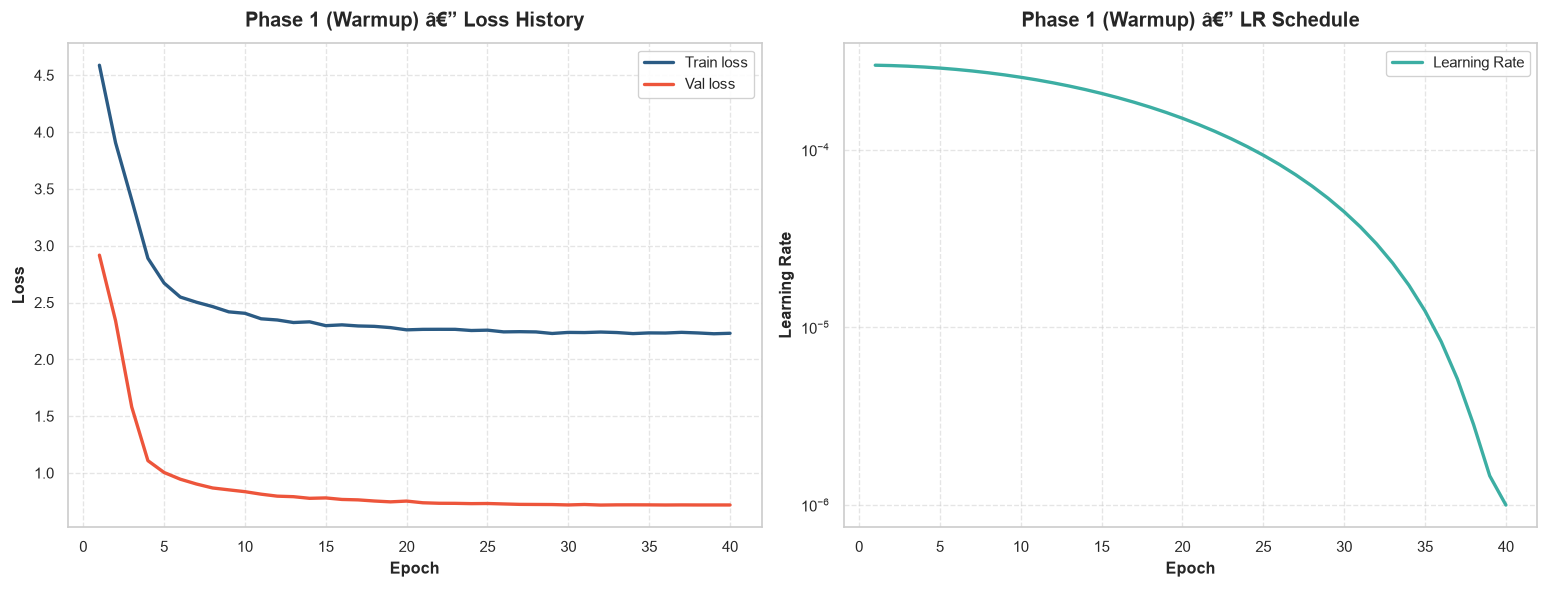

In [36]:
# Plot Phase 1 (Warmup) Training History
fig_stage1 = plot_training_history(
    history=result_warmup.history,
    stage="Phase 1 (Warmup)",
    cfg=notebook_cfg
)
plt.show()

In [37]:
# ============================================================================
# Phase 2: Joint End-to-End Finetuning (All Layers Unfrozen)
# ============================================================================
print(f"--- PHASE 2: Joint E2E Finetuning for {subject_str} ---")

# Unfreeze ALL parameters for end-to-end joint optimization
for param in model.parameters():
    param.requires_grad = True

e2e_epochs  = notebook_cfg["training"]["max_epochs"] - warmup_epochs
e2e_lr      = notebook_cfg["training"]["e2e_lr"]
trans_scale = notebook_cfg["training"]["transformer_lr_scale"]

train_cfg_e2e = TrainConfig.from_config(
    notebook_cfg["training"], 
    max_epochs=e2e_epochs,
    lr=e2e_lr
)
train_cfg_e2e.transformer_lr_scale = trans_scale
train_cfg_e2e.checkpoint_dir = notebook_cfg["training"]["checkpoint_dir"] + f"_e2e/{subject_str}"

result_e2e = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    prepare_batch=prepare_batch,
    loss_fn=loss_fn,
    device=device,
    cfg=train_cfg_e2e,
    resume=True
)
print(f"\nPhase 2 Joint E2E Complete. Best val loss: {result_e2e.best_val:.4f}")

# Load best model checkpoint for evaluation and visualization
best_ckpt = notebook_cfg["training"]["checkpoint_dir"] + f"_e2e/{subject_str}/best.pt"
best_model = copy.deepcopy(model)
load_checkpoint(best_ckpt, best_model, device)
best_model.eval()
print(f"Loaded best checkpoint from: {best_ckpt}")

# Combine histories for end-to-end curve plotting
combined_history = {
    "train": result_warmup.history["train"] + result_e2e.history["train"],
    "val":   result_warmup.history["val"] + result_e2e.history["val"],
    "lr":    result_warmup.history.get("lr", []) + result_e2e.history.get("lr", []),
    "_phase_boundary": warmup_epochs,
}

--- PHASE 2: Joint E2E Finetuning for P1 ---
  Differential LR groups:
    GAT/Decoder  : 3.00e-04
    Transformer  : 3.00e-05  (scale=0.1)
    KinSkip      : 1.00e-04  (regularized)

  GPU / Device Status
  OK  Device index    : cuda:0
  OK  GPU name        : NVIDIA GeForce GTX 1660 Ti
  OK  CUDA capability : sm_75
  OK  VRAM (total)    : 6,144 MB
  OK  VRAM allocated  : 650.7 MB
  OK  VRAM reserved   : 1960.0 MB
  OK  CUDA version    : 12.6
  OK  PyTorch build   : 2.8.0+cu126
  OK  AMP (FP16)      : YES -- Turing tensor cores active
  Optimizer : ADAMW  (weight_decay=0.05)
  Scheduler : COSINE  (T_max=160, eta_min=1e-06)

Starting fresh training run  (checkpoint_dir=outputs/checkpoints_e2e_e2e/P1)



  Ep    1 [train]:   0%|          | 0/59 [00:00<?, ?batch/s]

  Ep    1 [val  ]:   0%|          | 0/16 [00:00<?, ?batch/s]

  Ep    2 [train]:   0%|          | 0/59 [00:00<?, ?batch/s]

  Ep    2 [val  ]:   0%|          | 0/16 [00:00<?, ?batch/s]

...

  Ep   41 [train]:   0%|          | 0/59 [00:00<?, ?batch/s]

  Ep   41 [val  ]:   0%|          | 0/16 [00:00<?, ?batch/s]

  Ep   42 [train]:   0%|          | 0/59 [00:00<?, ?batch/s]

  Ep   42 [val  ]:   0%|          | 0/16 [00:00<?, ?batch/s]

Early stop at epoch 42 (no val improvement for 30 epochs).

Training done.  Best val loss = 0.6348
Checkpoints saved to: D:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\outputs\checkpoints_e2e_e2e\P1

Phase 2 Joint E2E Complete. Best val loss: 0.6348
Loaded checkpoint <- outputs/checkpoints_e2e_e2e/P1/best.pt  (best_val=0.6348)
Loaded best checkpoint from: outputs/checkpoints_e2e_e2e/P1/best.pt


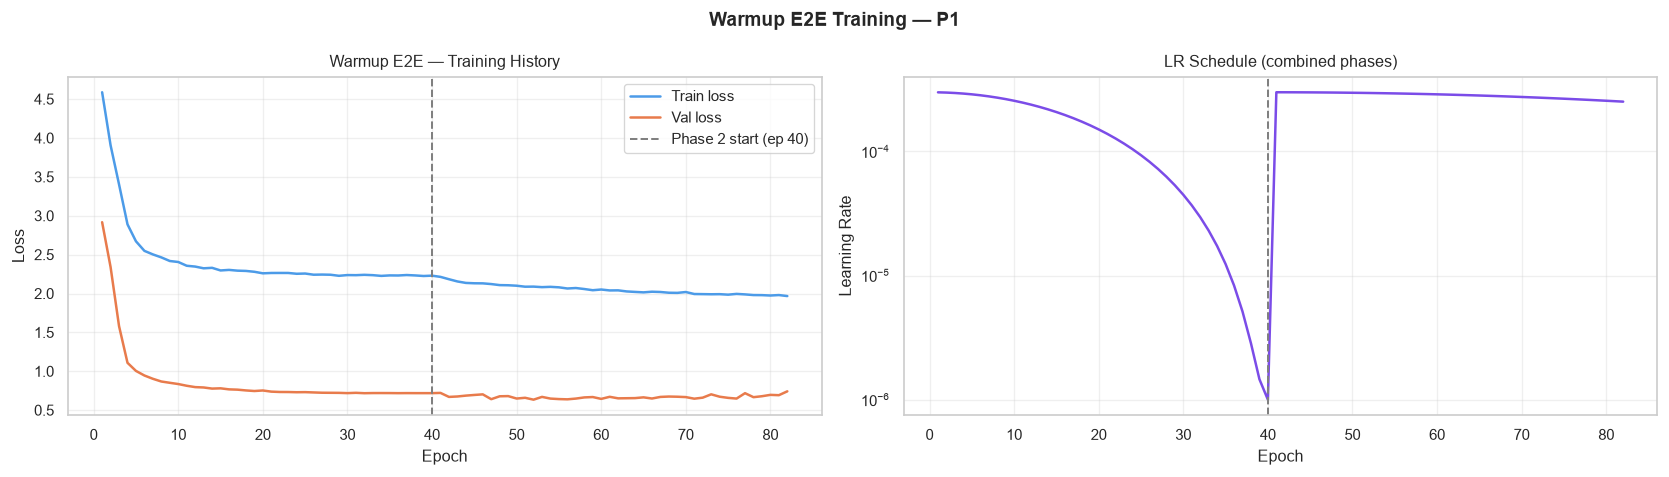

Phase 1 (warmup)  best val: 0.7180  (40 epochs)
Phase 2 (E2E)     best val: 0.6348  (160 epochs)


In [38]:
# Plot Combined Warmup + Joint E2E Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor="white")

_n = len(combined_history["train"])
_epochs = np.arange(1, _n + 1)
_pb = combined_history.get("_phase_boundary", warmup_epochs)

# Loss curves
ax = axes[0]
ax.plot(_epochs, combined_history["train"], label="Train loss", color="#4C9BE8", linewidth=1.5)
ax.plot(_epochs, combined_history["val"],   label="Val loss",   color="#E87B4C", linewidth=1.5)
ax.axvline(_pb, color="gray", linestyle="--", linewidth=1.2, label=f"Phase 2 start (ep {_pb})")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title("Warmup E2E — Training History")
ax.legend(); ax.grid(alpha=0.3)

# LR curves
ax2 = axes[1]
if combined_history.get("lr"):
    ax2.plot(_epochs[:len(combined_history["lr"])], combined_history["lr"], color="#7B4CE8", linewidth=1.5)
    ax2.axvline(_pb, color="gray", linestyle="--", linewidth=1.2)
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Learning Rate")
    ax2.set_title("LR Schedule (combined phases)")
    ax2.set_yscale("log"); ax2.grid(alpha=0.3)

plt.suptitle(f"Warmup E2E Training — {subject_str}", fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Phase 1 (warmup)  best val: {result_warmup.best_val:.4f}  ({warmup_epochs} epochs)")
print(f"Phase 2 (E2E)     best val: {result_e2e.best_val:.4f}  ({e2e_epochs} epochs)")

In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION — Full metric suite: RMSE, nRMSE, MAE, Pearson r, R^2, VAF
# ─────────────────────────────────────────────────────────────────────────────
EMG_NAMES = ["DELT", "BIC", "TRI", "BRA", "FCR"]

best_model.eval()
# Collect predictions on the test set
P_test, Y_test = collect_predictions(
    best_model, test_loader, prepare_batch, device,
    n_channels=len(EMG_NAMES), use_amp=notebook_cfg["training"]["use_amp"],
)
# Compute all 6 metrics
metrics = compute_metrics(P_test, Y_test, channel_names=EMG_NAMES)

# Print ASCII table
print("\n" + metrics.as_table() + "\n")

# Pandas DataFrame for export / display
rows = list(zip(
    metrics.channel_names,
    metrics.rmse, metrics.nrmse, metrics.mae,
    metrics.pearson, metrics.r2, metrics.vaf,
))
df = pd.DataFrame(rows,
    columns=["Channel", "RMSE", "nRMSE%", "MAE", "Pearson r", "R^2", "VAF%"])
df.loc["MEAN"] = ["MEAN"] + [df[c].mean() for c in df.columns[1:]]
# display(df.round(4))

# Publication threshold check (VAF > 80% per Winter 1990)
vaf_pass = int((metrics.vaf >= 80.0).sum())
print(f"VAF >= 80% threshold: {vaf_pass}/{len(EMG_NAMES)} channels passed")


Channel                RMSE   nRMSE%      MAE  Pearson r      R^2     VAF%
--------------------------------------------------------------------------
DELT                 0.3903     7.14   0.2598     0.9329   0.8381    85.28
BIC                  0.4804     5.82   0.3086     0.8938   0.7648    77.40
TRI                  0.7758     5.43   0.5115     0.7447   0.4513    45.53
BRA                  0.3405     6.40   0.2486     0.8813   0.7660    77.17
FCR                  0.5646     4.84   0.3114     0.8642   0.6595    68.59
--------------------------------------------------------------------------
 MEAN                0.5103     5.93   0.3280     0.8634   0.6959    70.79

VAF >= 80% threshold: 1/5 channels passed


d:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\main\plots.py:603: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\interpretability_triptych.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\interpretability_triptych.pdf


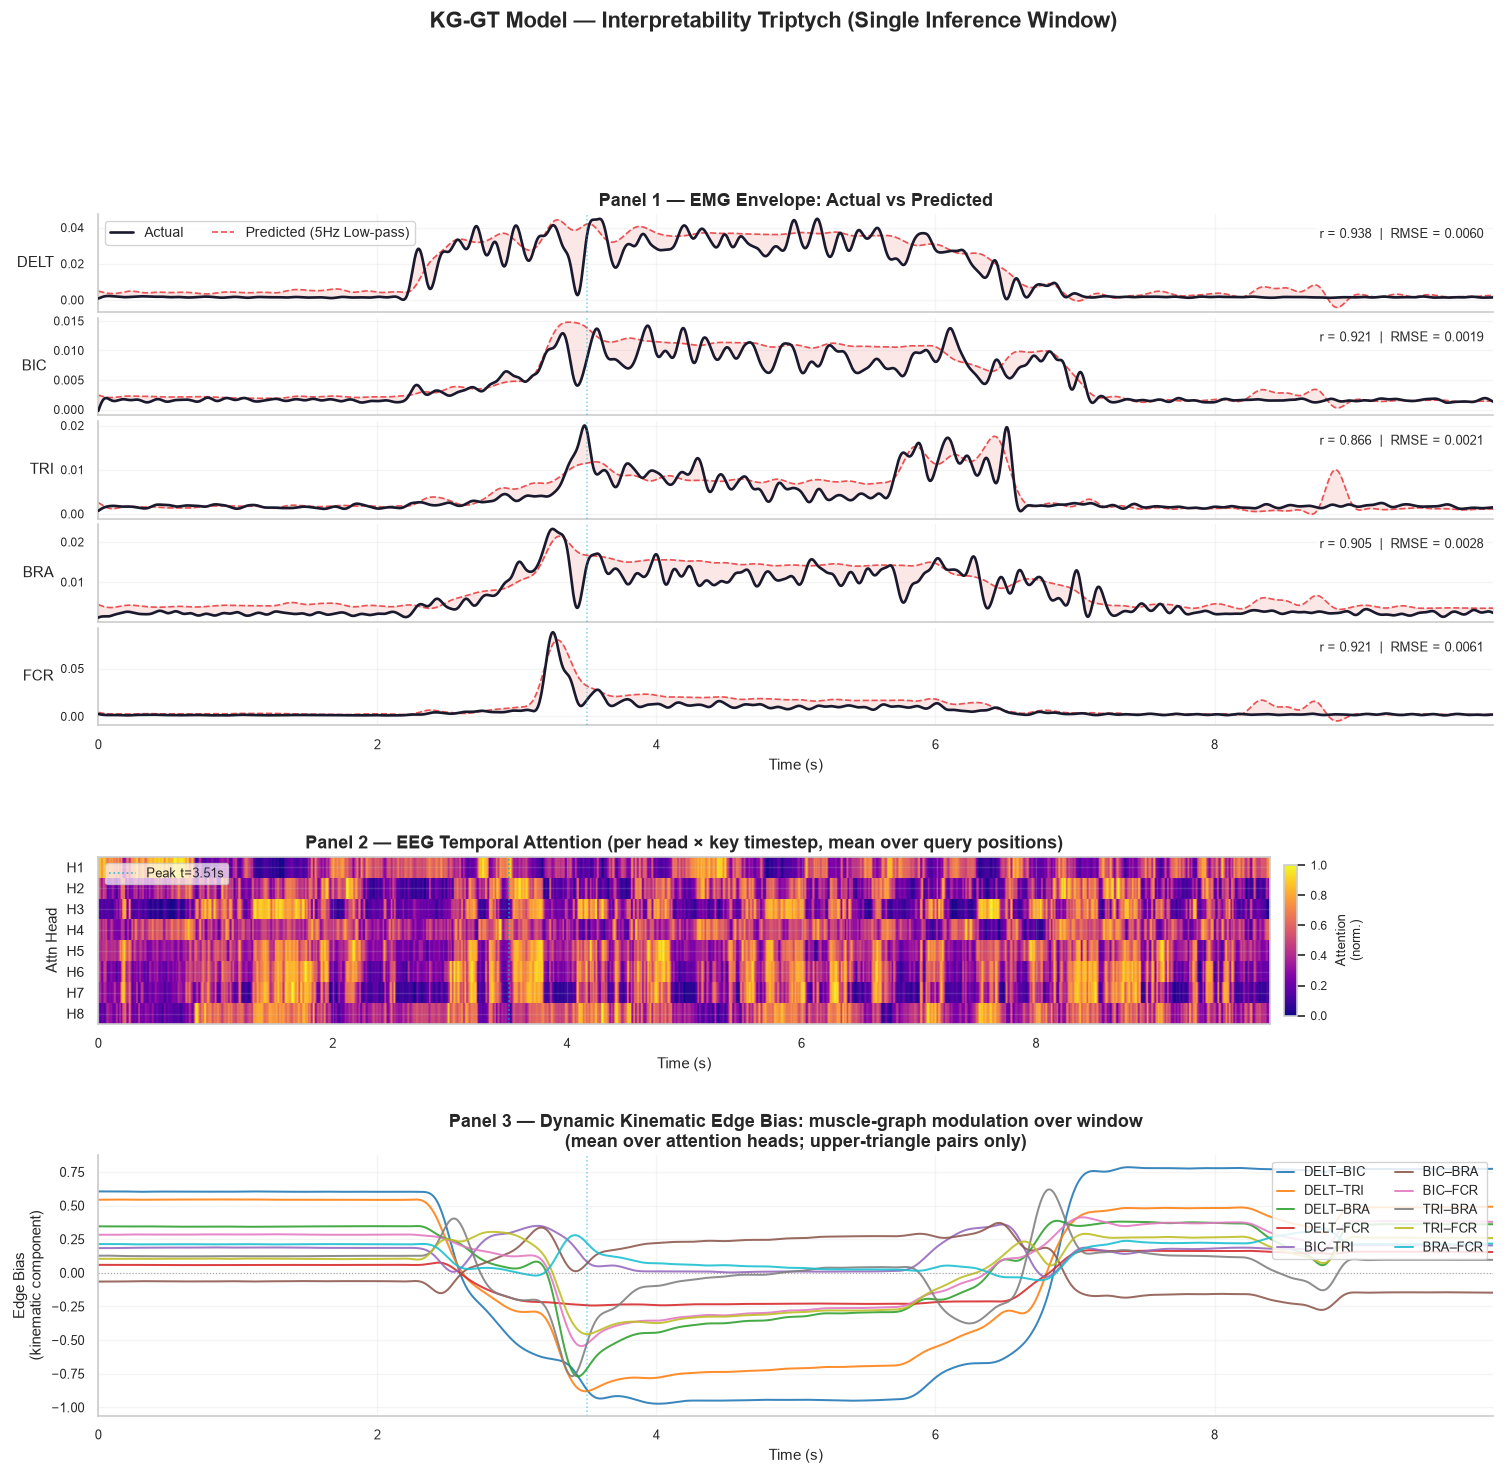

Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\kin_skip_over_time.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\kin_skip_over_time.pdf


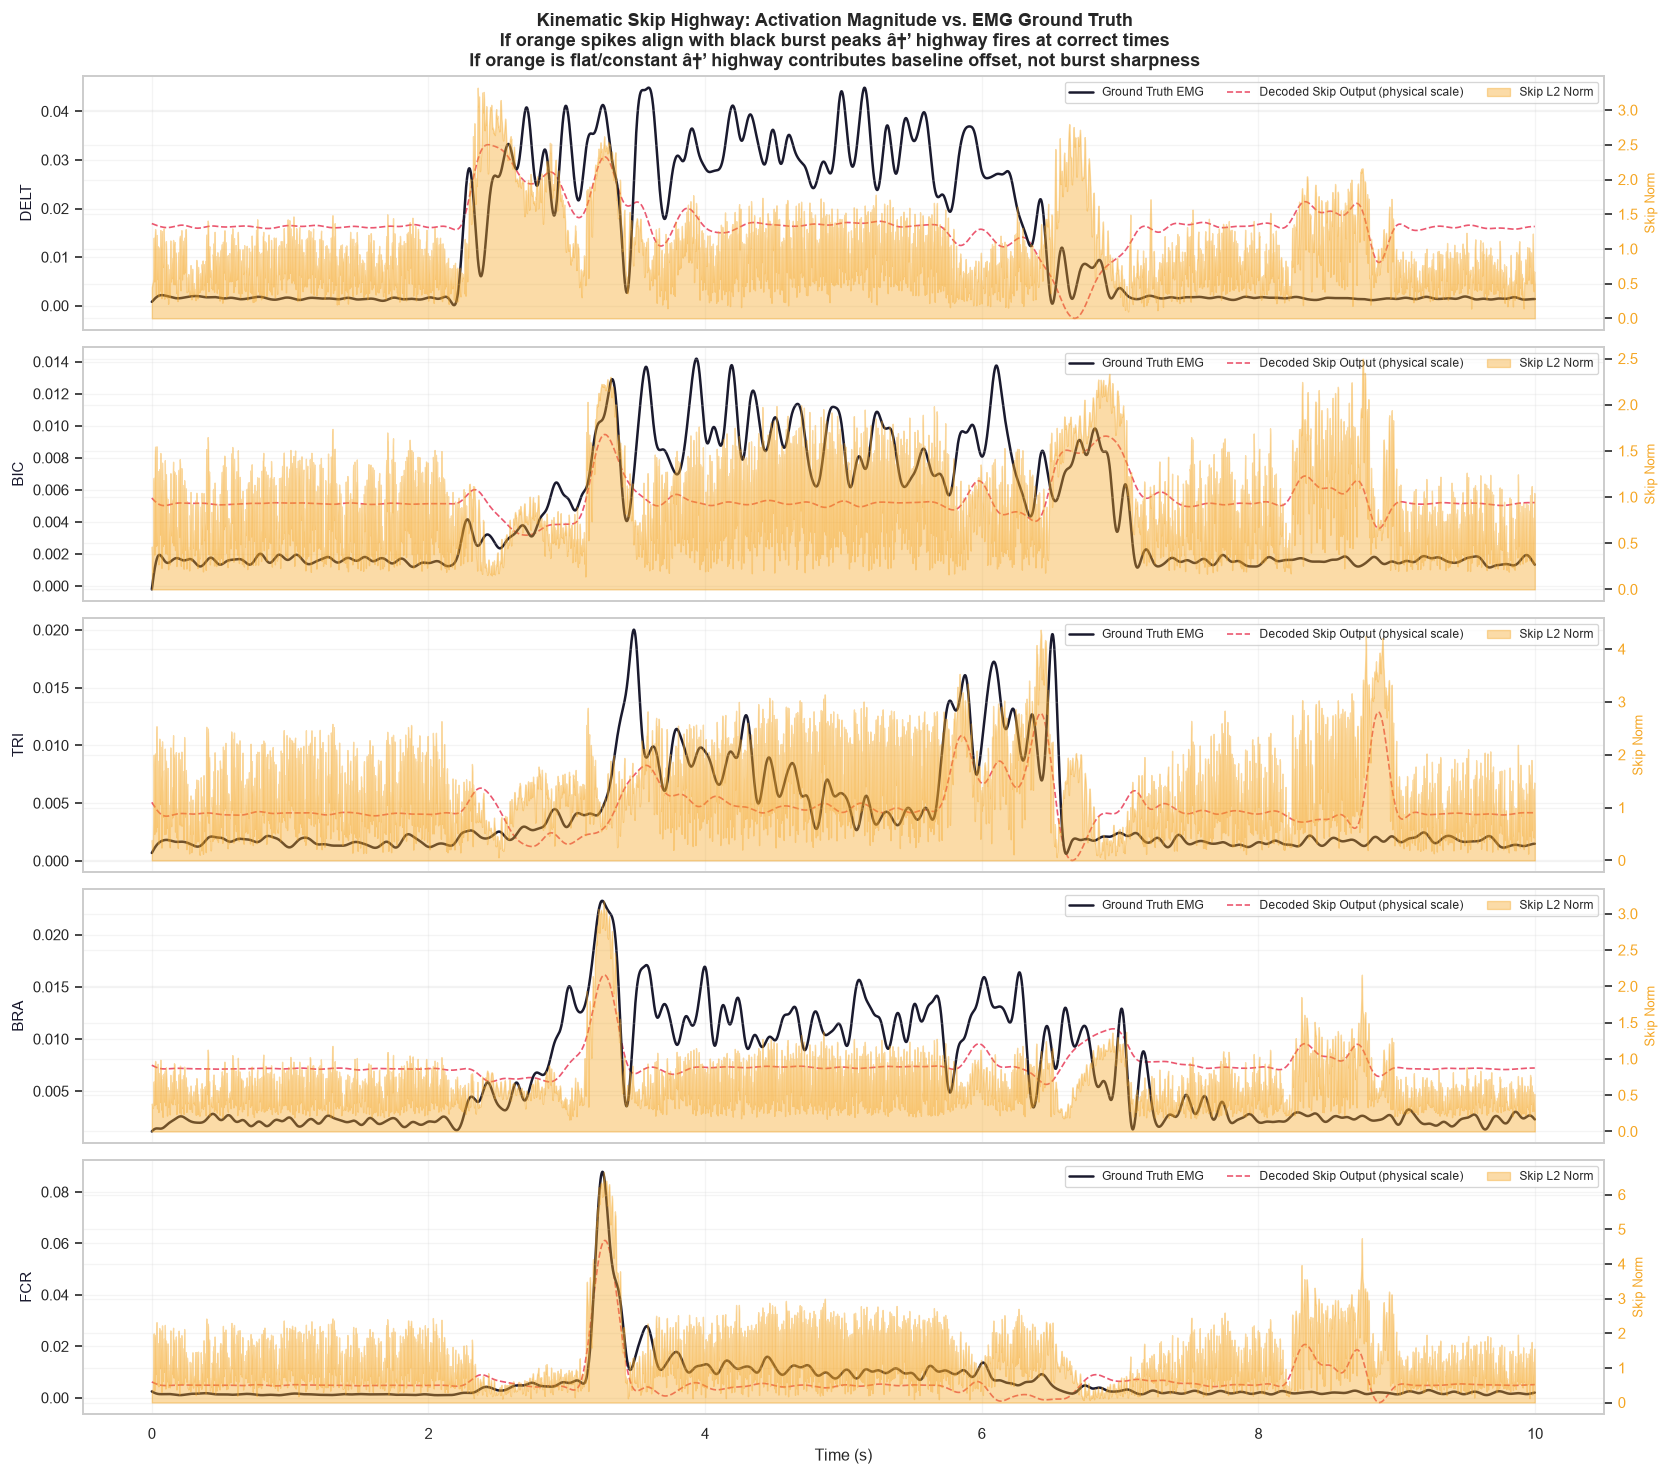

In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# INTERPRETABILITY — Dynamic Continuous Attention Triptych & Kinematic Skip Highway
# ─────────────────────────────────────────────────────────────────────────────
from scipy.ndimage import gaussian_filter1d
from main.plots import plot_interpretability_triptych, plot_kin_skip_over_time

fs = notebook_cfg["data"].get("fs_eeg", 500.0)
eeg_full, kin_full, emg_full, block_start_idx = test_ds._windows[0]
start_idx = block_start_idx + int(0.0 * fs)
end_idx   = block_start_idx + int(10.0 * fs)

raw_eeg = torch.tensor(eeg_full[start_idx : end_idx])
raw_kin = torch.tensor(kin_full[start_idx : end_idx])
raw_emg = torch.tensor(emg_full[start_idx : end_idx])

# Prepare window sample
model_inputs, emg_norm = prepare_batch(raw_eeg.unsqueeze(0), raw_kin.unsqueeze(0), raw_emg.unsqueeze(0))
eeg_b = model_inputs["eeg"]
kin_b = model_inputs["kin"]
emg_b = emg_norm

best_model.eval()
for layer in best_model.encoder.layers:
    layer.mhsa.attention_temperature = 4.0

with torch.no_grad():
    pred_b = best_model(eeg_b, kin_b)

pred_np = pred_b[0].cpu().float().numpy()   
true_np = emg_b[0].cpu().float().numpy()    

emg_mean_np = emg_mean.cpu().numpy()
emg_std_np  = emg_std.cpu().numpy()
pred_np = pred_np * emg_std_np + emg_mean_np
true_np = true_np * emg_std_np + emg_mean_np

# Extract temporal attention & smooth
eeg_attn_np = best_model.encoder.layers[-1].mhsa.last_attn_weights[0].cpu().float().numpy()
eeg_attn_np = gaussian_filter1d(eeg_attn_np, sigma=3.0, axis=-1)

# Extract kinematic edge bias
if hasattr(best_model.gat, "last_kin_edge_bias"):
    kin_edge_np = best_model.gat.last_kin_edge_bias[0].cpu().float().numpy()
else:
    kin_edge_np = np.zeros((pred_np.shape[0], 4, len(EMG_NAMES), len(EMG_NAMES)))

KIN_FEATURE_NAMES = [          
    "p_wrist_x", "p_wrist_y", "p_wrist_z",
    "p_index_x", "p_index_y", "p_index_z",
    "p_thumb_x", "p_thumb_y", "p_thumb_z",
    "d_grip",    "F_L",        "F_G",    
]

# 1. Interpretability Triptych
fig_triptych = plot_interpretability_triptych(
    pred=pred_np,
    target=true_np,
    eeg_attn=eeg_attn_np,
    kin_edge_bias=kin_edge_np,
    muscle_names=EMG_NAMES,
    kin_feature_names=KIN_FEATURE_NAMES,
    fs=fs,
    smooth_hz=5.0,
    cfg=notebook_cfg,
)
plt.show()

# 2. Kinematic Skip Highway Activation Over Time
fig_skip = plot_kin_skip_over_time(
    model=best_model,
    eeg_window=eeg_b,
    kin_window=kin_b,
    emg_target=true_np,
    emg_mean=emg_mean,
    emg_std=emg_std,
    smooth_hz=5.0,
    emg_names=EMG_NAMES,
    fs=fs,
    cfg=notebook_cfg,
)
plt.show()

Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\residual_decomposition.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\residual_decomposition.pdf


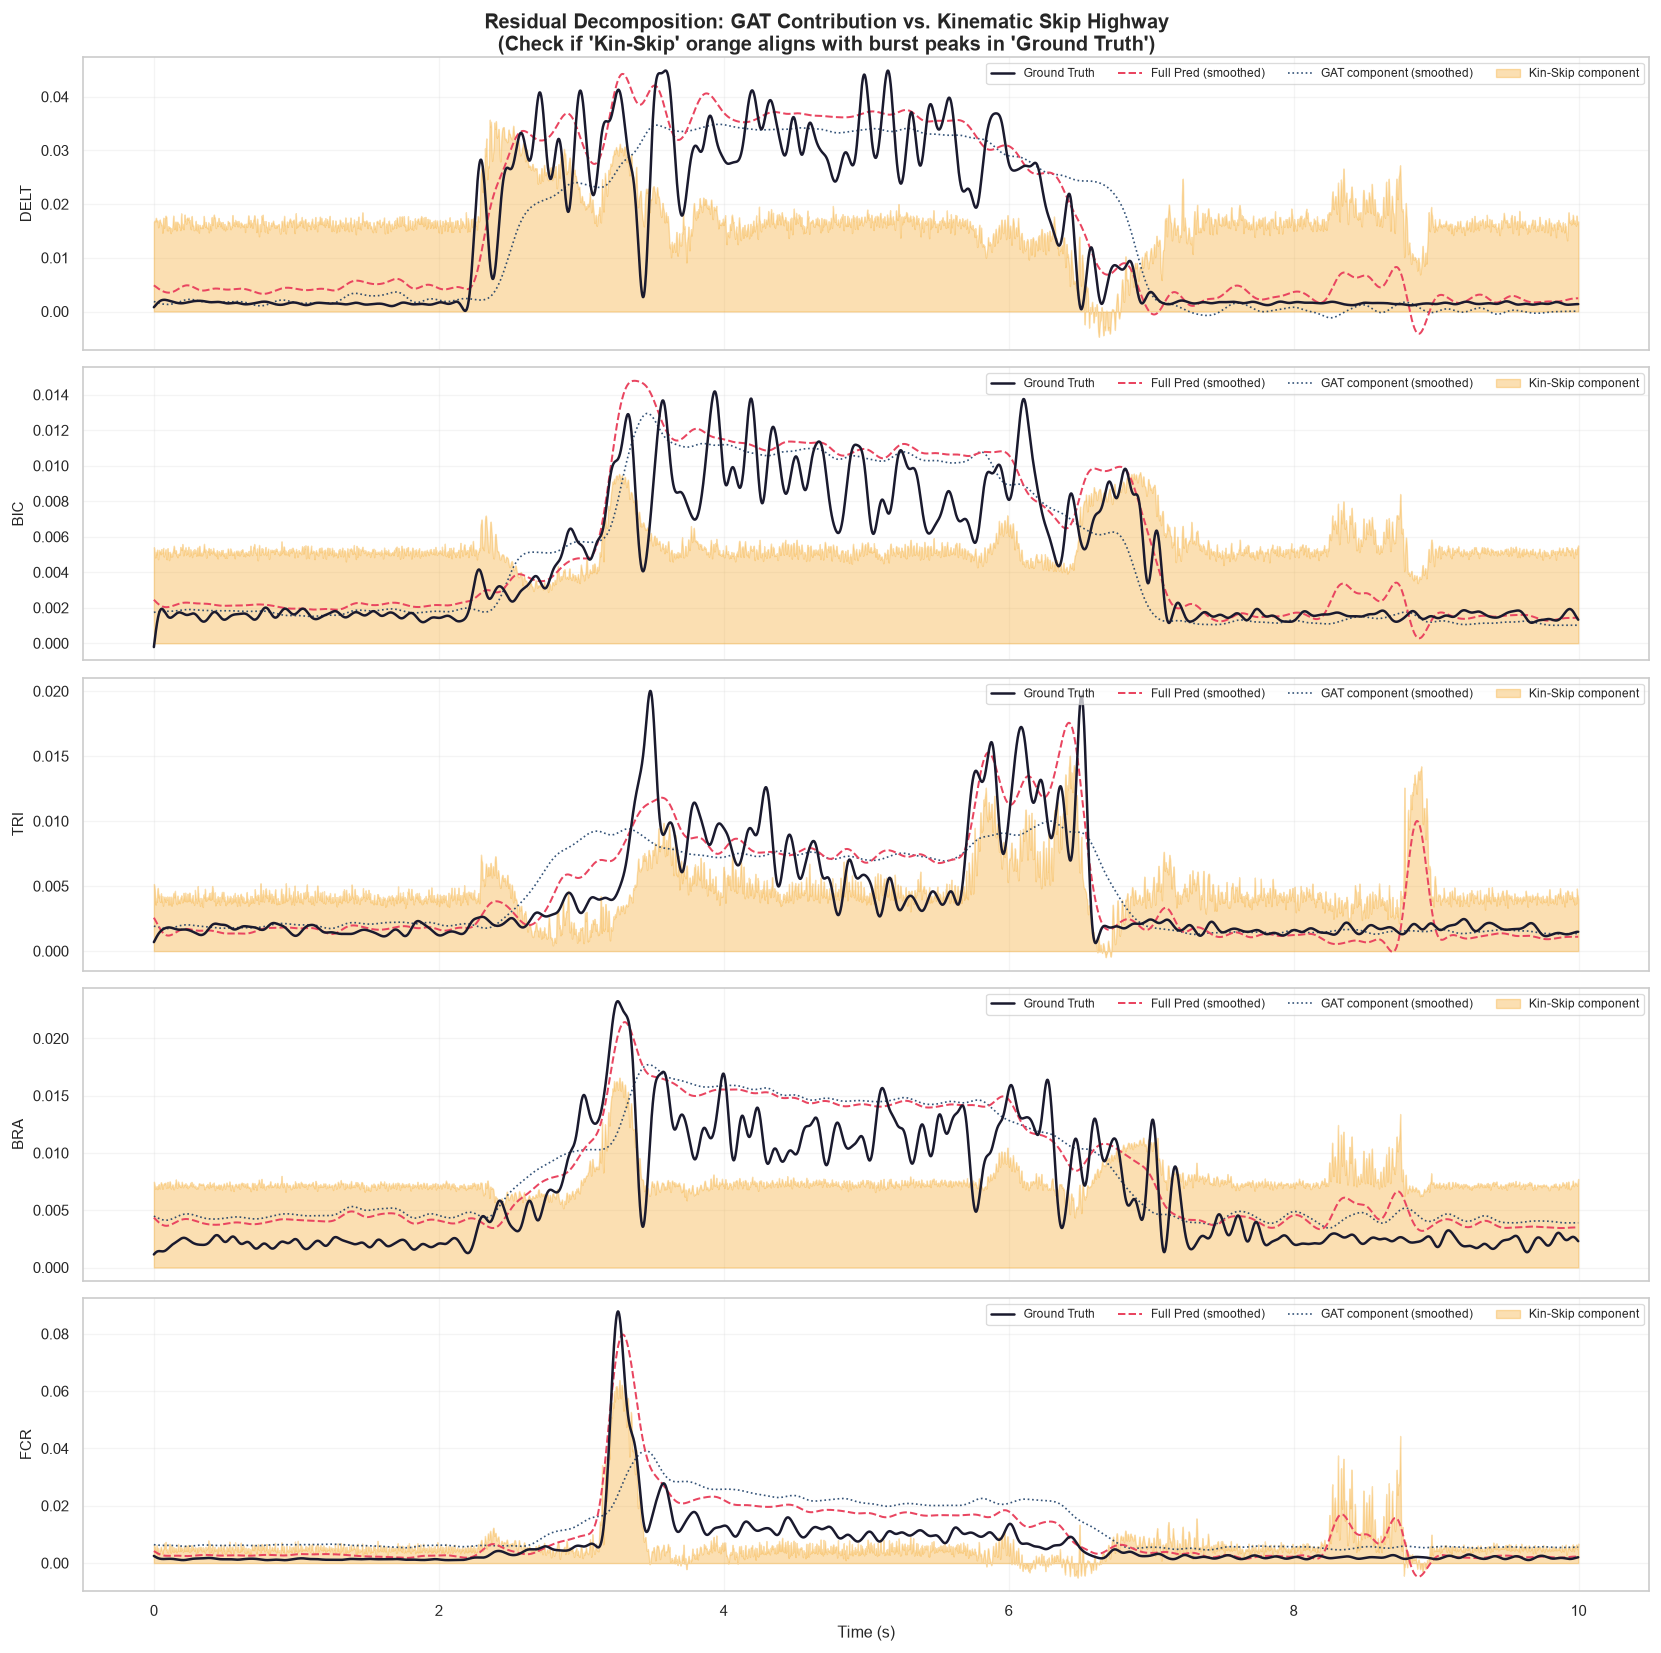

In [41]:
# ── DIAGNOSTIC: Residual Decomposition (GAT vs Kinematic Skip) ────────────
from main.plots import plot_residual_decomposition

fig_res = plot_residual_decomposition(
    model=best_model,
    eeg_window=eeg_b,
    kin_window=kin_b,
    emg_target=true_np,
    emg_mean=emg_mean,
    emg_std=emg_std,
    smooth_hz=5.0,
    emg_names=EMG_NAMES,
    fs=fs,
    cfg=notebook_cfg,
)
plt.show()

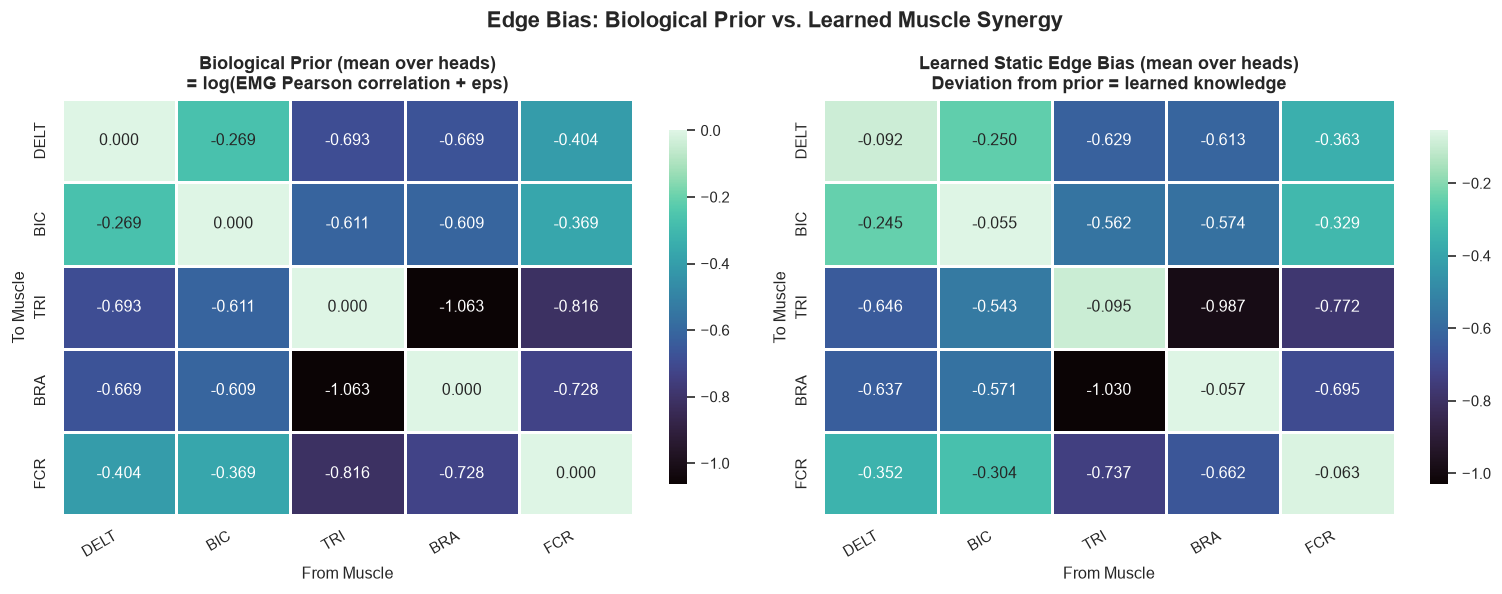

findfont: Failed to find font weight semibold, now using 700.


Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\muscle_synergy_matrix.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\muscle_synergy_matrix.pdf


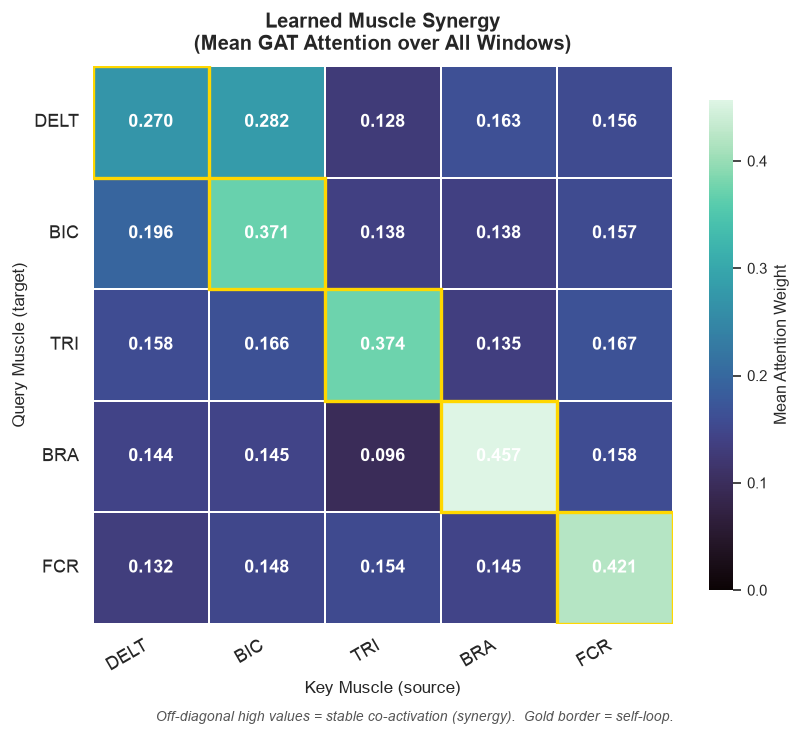

Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\channel_correlation_matrix.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\channel_correlation_matrix.pdf


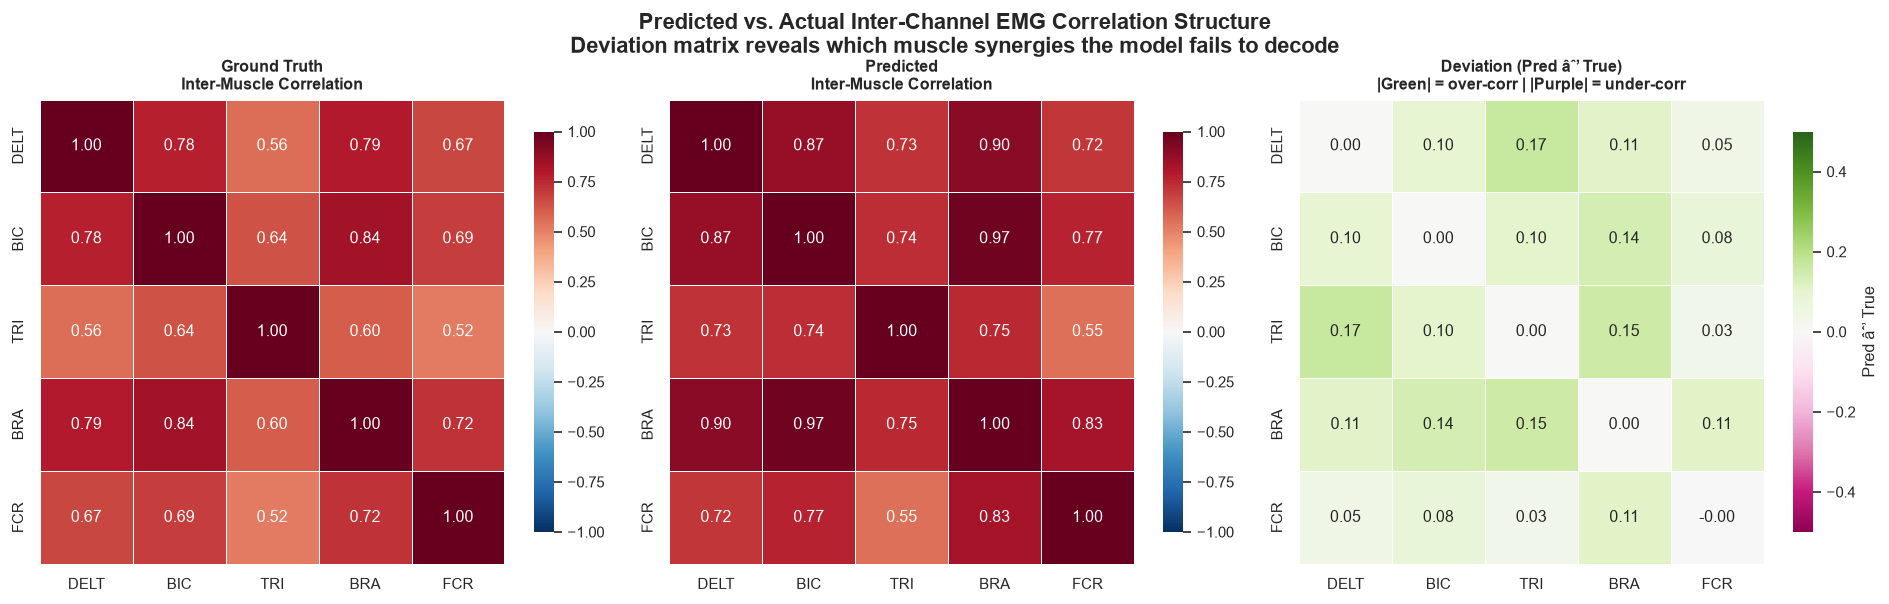

Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\emg_error_analysis.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\emg_error_analysis.pdf


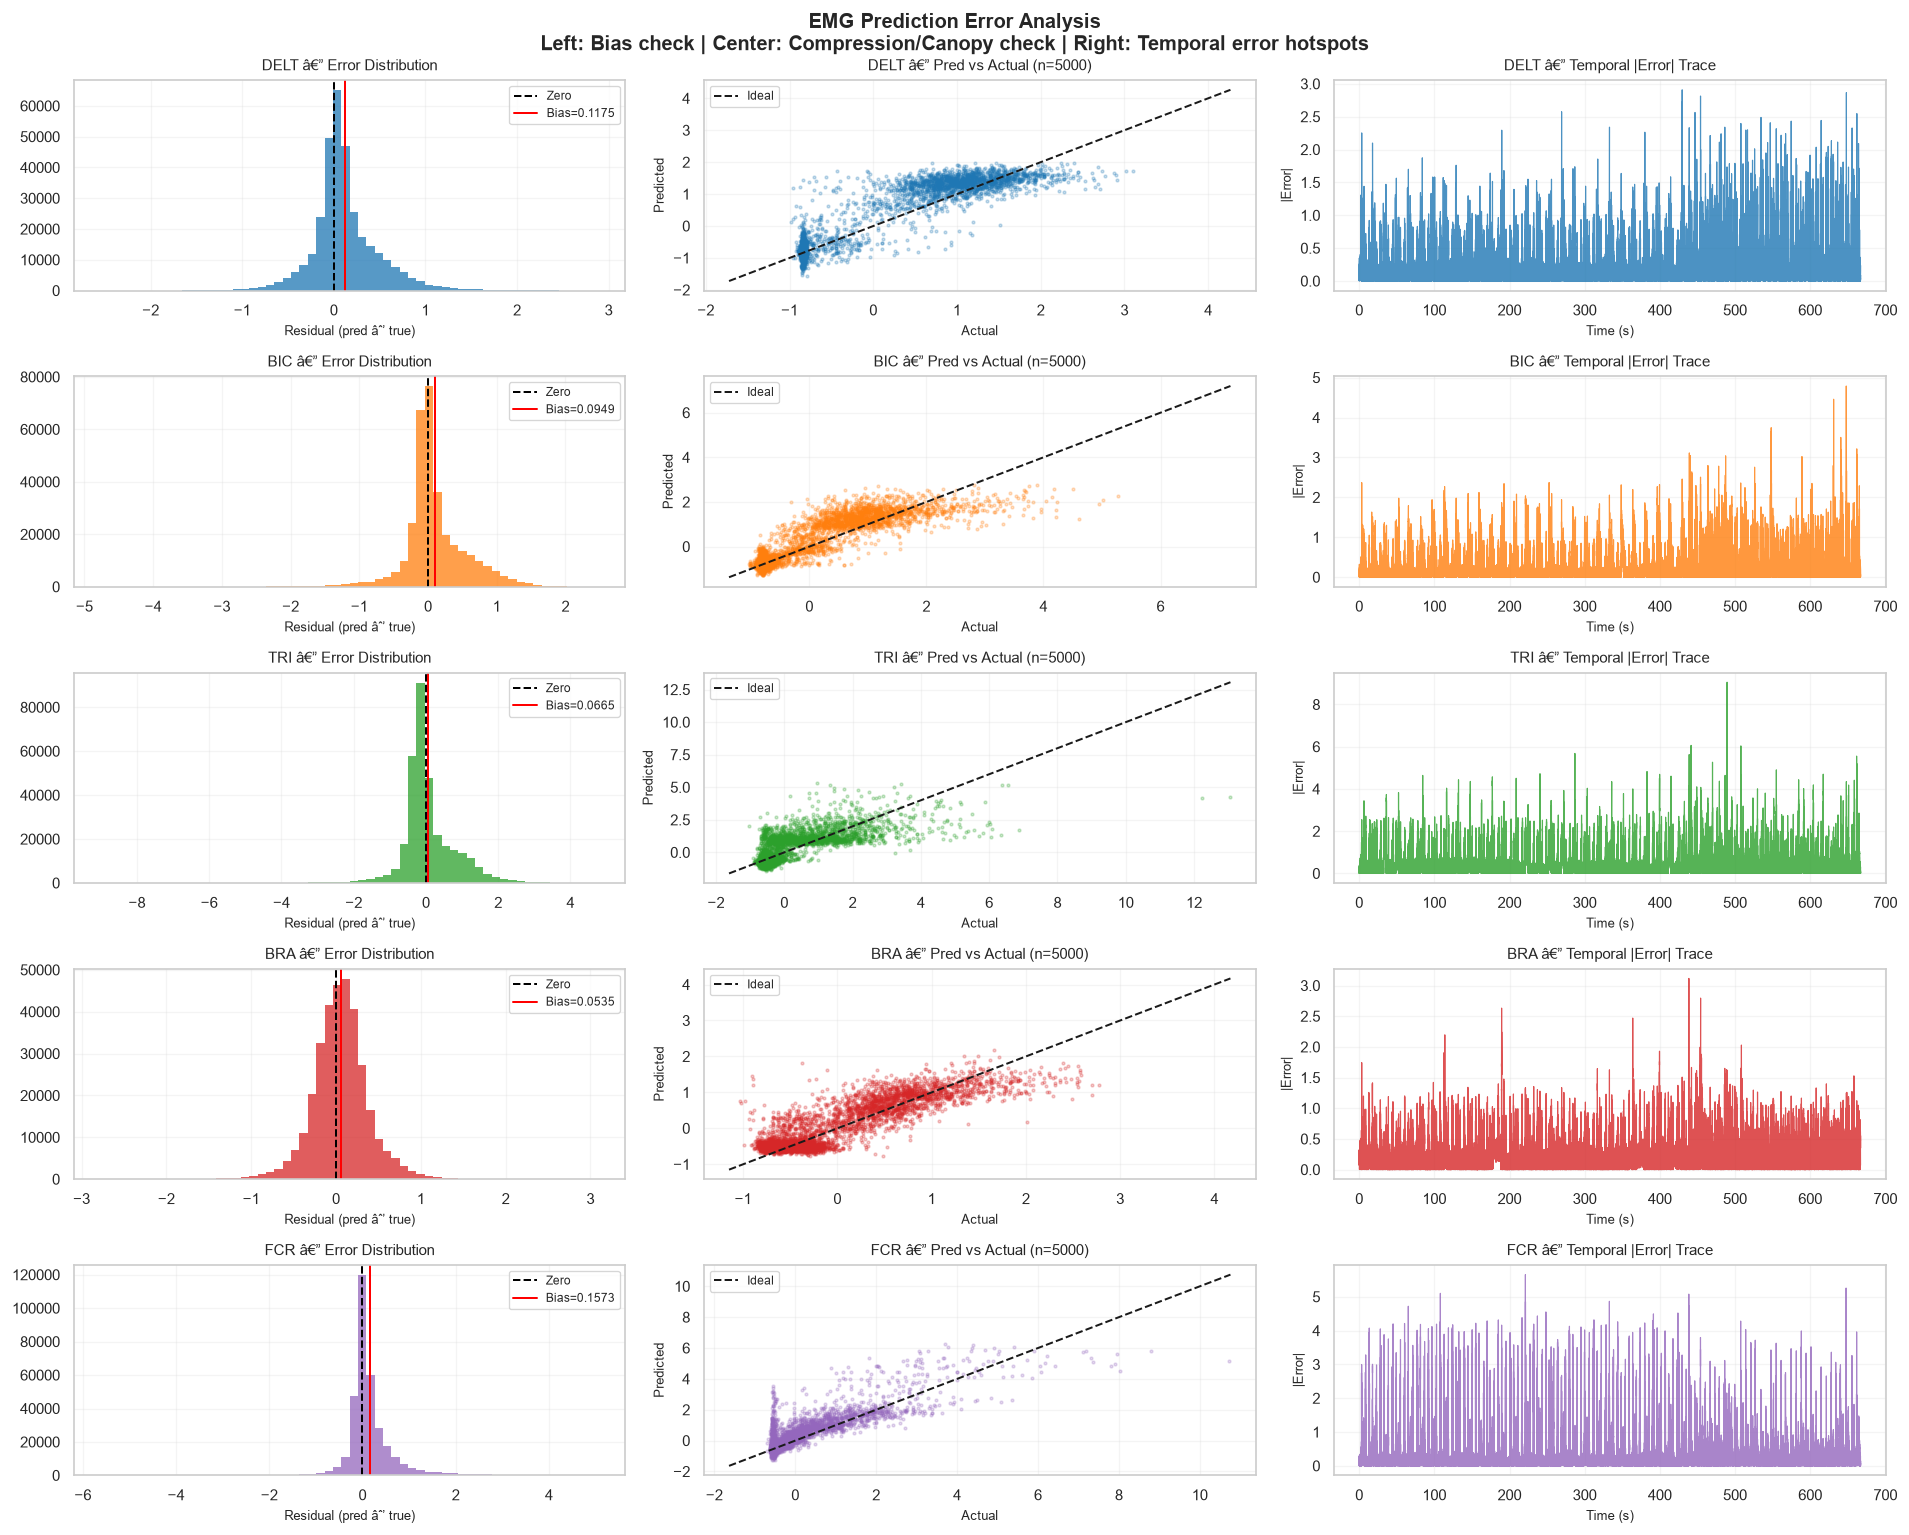

Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\kin_edge_linear_weights.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\kin_edge_linear_weights.pdf


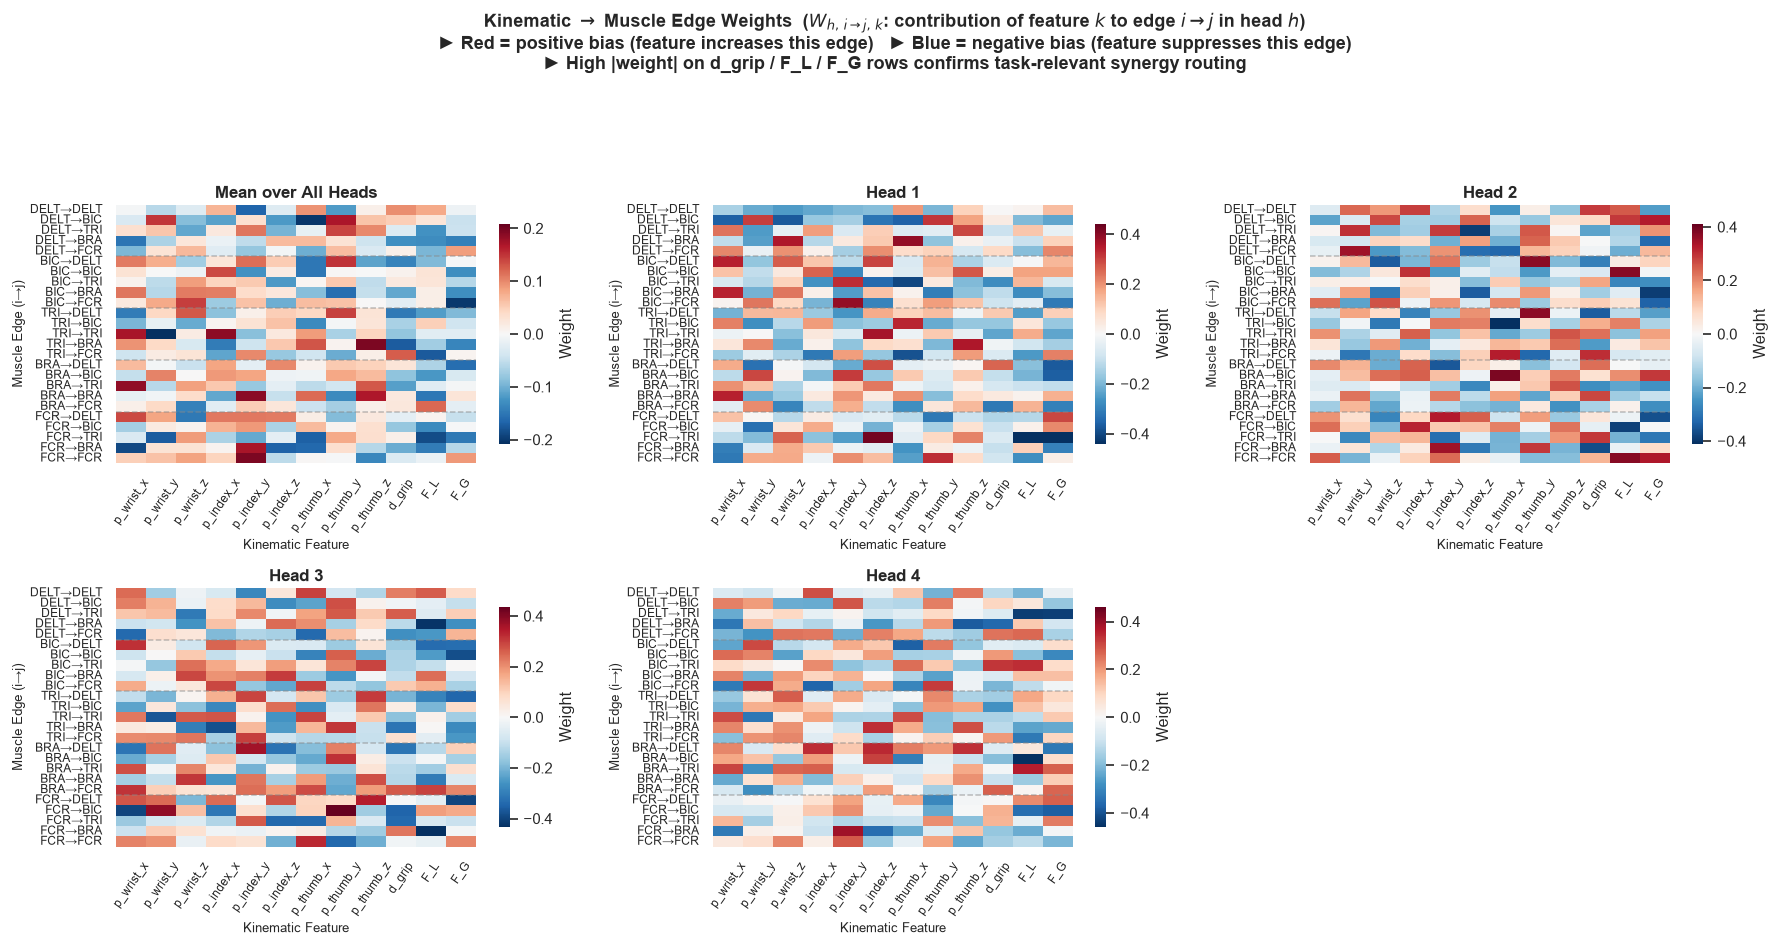


Inspect high |weight| rows on d_grip / F_L / F_G for key insights.


In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# STATIC EDGE BIAS + MUSCLE SYNERGY MATRIX + KINEMATIC WEIGHT HEATMAP
# ─────────────────────────────────────────────────────────────────────────────
import seaborn as sns
from main.plots import (
    plot_muscle_synergy_matrix,
    plot_kin_edge_linear_weights,
    plot_channel_correlation_matrix,
    plot_emg_error_analysis
)

# ── 1. Biological prior vs. learned static edge bias ──────────────────────
gat = best_model.gat
learned_bias = gat.edge_bias.detach().cpu().numpy()    # (H, N, N)
prior_anchor  = gat.edge_prior_anchor.cpu().numpy()    # (H, N, N)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")
kw = dict(
    annot=True, fmt=".3f", cmap="mako",
    xticklabels=EMG_NAMES, yticklabels=EMG_NAMES,
    cbar_kws={"shrink": 0.85}, linewidths=0.8, linecolor="white",
)
sns.heatmap(prior_anchor.mean(0), ax=axes[0], **kw)
axes[0].set_title("Biological Prior (mean over heads)\n= log(EMG Pearson correlation + eps)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("From Muscle"); axes[0].set_ylabel("To Muscle")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")

sns.heatmap(learned_bias.mean(0), ax=axes[1], **kw)
axes[1].set_title("Learned Static Edge Bias (mean over heads)\nDeviation from prior = learned knowledge", fontsize=11, fontweight="bold")
axes[1].set_xlabel("From Muscle"); axes[1].set_ylabel("To Muscle")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.suptitle("Edge Bias: Biological Prior vs. Learned Muscle Synergy", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 2. GAT attention synergy matrix (full test set) ───────────────────────
all_attn = []
best_model.eval()
with torch.no_grad():
    for raw_eeg, raw_kin, raw_emg in test_loader:
        model_inputs, _ = prepare_batch(raw_eeg, raw_kin, raw_emg)
        best_model(model_inputs["eeg"], model_inputs["kin"])
        if hasattr(best_model.gat, "last_attn_weights"):
            all_attn.append(best_model.gat.last_attn_weights.cpu().numpy())

if all_attn:
    all_attn_np = np.concatenate(all_attn, axis=0)   # (B*T, H, N, N)
    fig_syn = plot_muscle_synergy_matrix(all_attn_np, EMG_NAMES, cfg=notebook_cfg)
    plt.show()

# ── 3. Predicted vs Actual Inter-Muscle Correlation & EMG Error Analysis ─
all_preds_list, all_targets_list = [], []
best_model.eval()
with torch.no_grad():
    for raw_eeg, raw_kin, raw_emg in test_loader:
        model_inputs, emg_norm = prepare_batch(raw_eeg, raw_kin, raw_emg)
        pred = best_model(model_inputs["eeg"], model_inputs["kin"])
        all_preds_list.append(pred.cpu().float().numpy())
        all_targets_list.append(emg_norm.cpu().float().numpy())

all_preds_flat   = np.concatenate(all_preds_list,   axis=0).reshape(-1, len(EMG_NAMES))
all_targets_flat = np.concatenate(all_targets_list, axis=0).reshape(-1, len(EMG_NAMES))

fig_corr = plot_channel_correlation_matrix(
    y_pred=all_preds_flat,
    y_true=all_targets_flat,
    emg_names=EMG_NAMES,
    cfg=notebook_cfg,
)
plt.show()

fig_err = plot_emg_error_analysis(
    y_pred=all_preds_flat,
    y_true=all_targets_flat,
    emg_names=EMG_NAMES,
    fs=fs,
    cfg=notebook_cfg,
)
plt.show()

# ── 4. Transparent kinematic -> edge weight matrix ────────────────────────
if hasattr(best_model.gat, "kin_edge_linear"):
    W = best_model.gat.kin_edge_linear.weight.detach().cpu().numpy()
    gat_cfg = notebook_cfg["model"]["gat"]
    fig_kin = plot_kin_edge_linear_weights(
        weight_matrix=W,
        muscle_names=EMG_NAMES,                       
        kin_feature_names=KIN_FEATURE_NAMES,
        num_heads=gat_cfg["heads"],
        n_nodes=5,
        cfg=notebook_cfg,
    )
    plt.show()
    print("\nInspect high |weight| rows on d_grip / F_L / F_G for key insights.")

Generating Plot 1: Neural-Mechanical Latency Lag Analysis...
Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\neural_mechanical_latency_lag.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\neural_mechanical_latency_lag.pdf


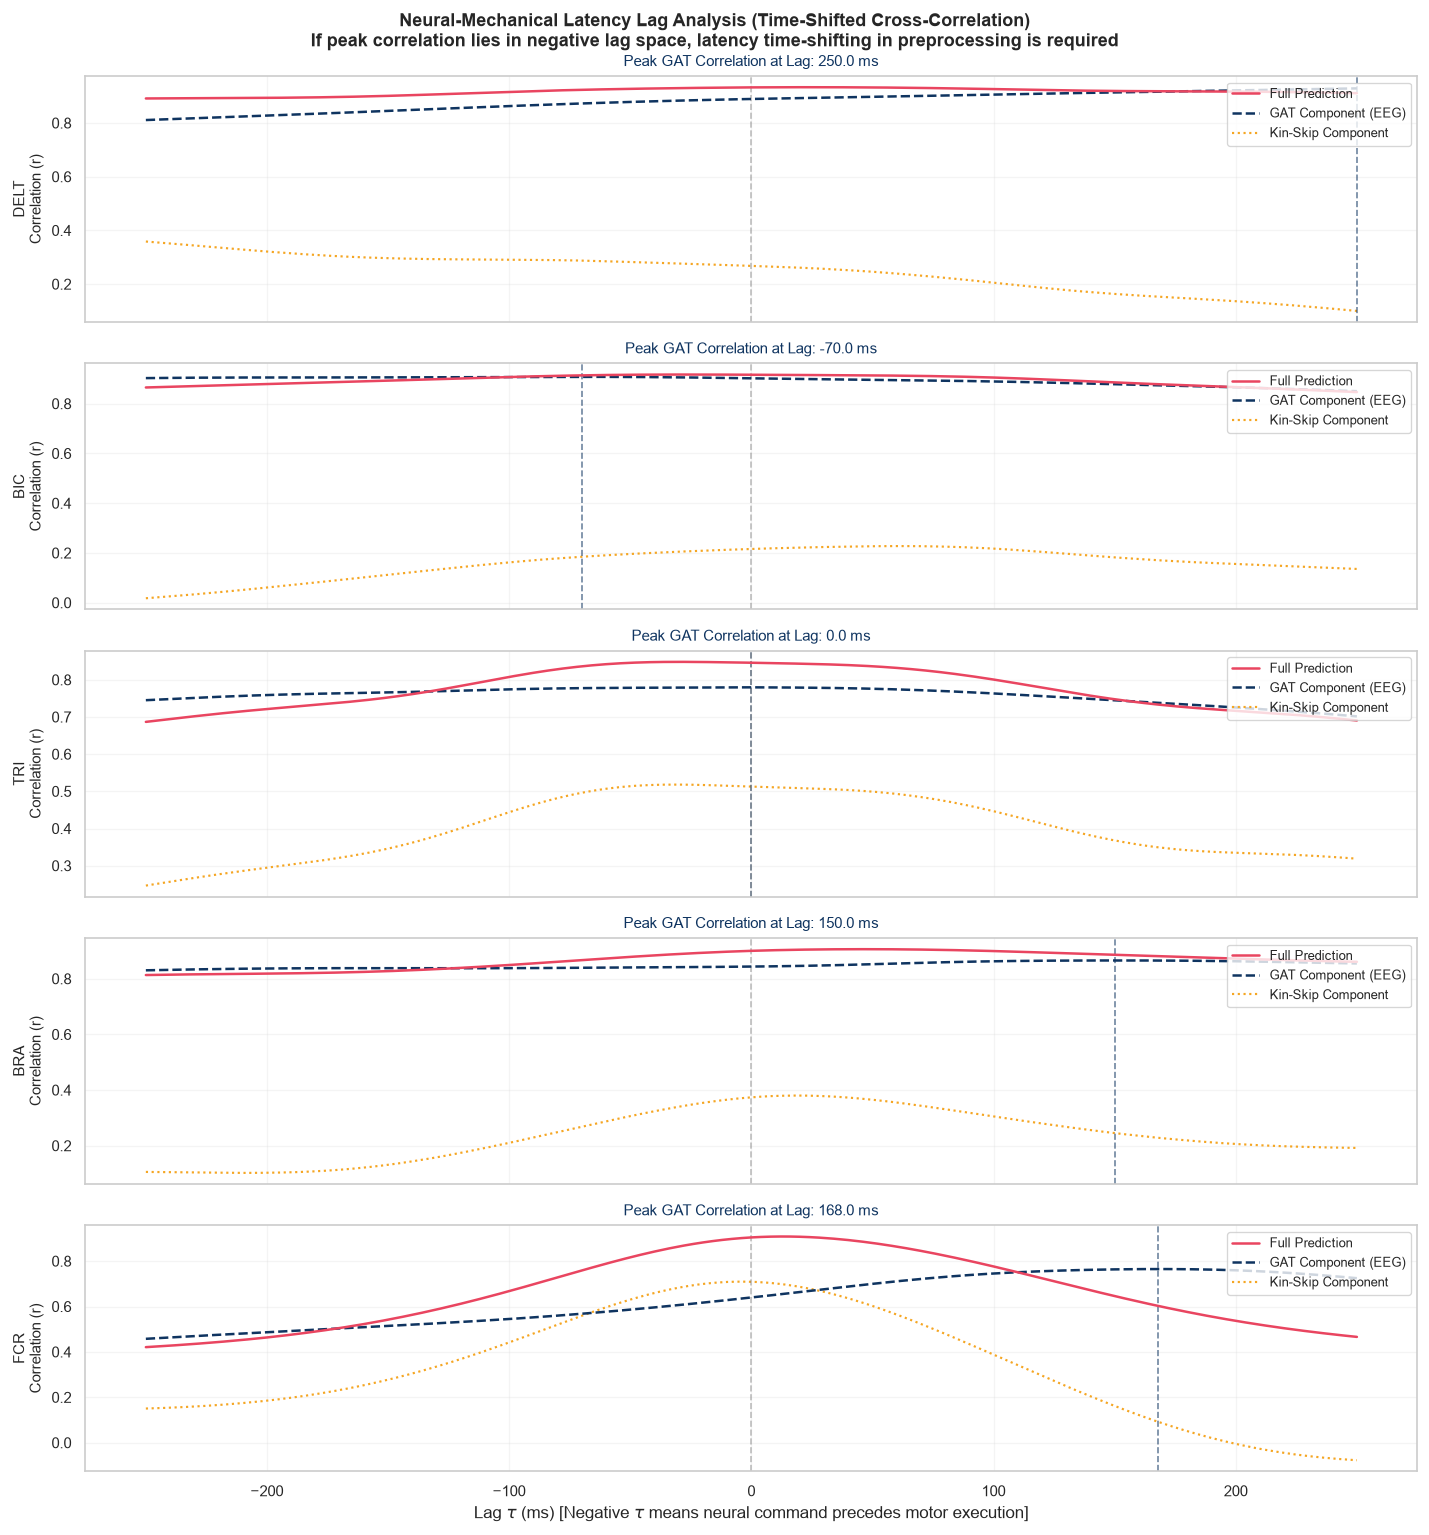


Generating Plot 2: Spectral Power Decomposition (Welch's PSD)...
Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\spectral_power_decomposition.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\spectral_power_decomposition.pdf


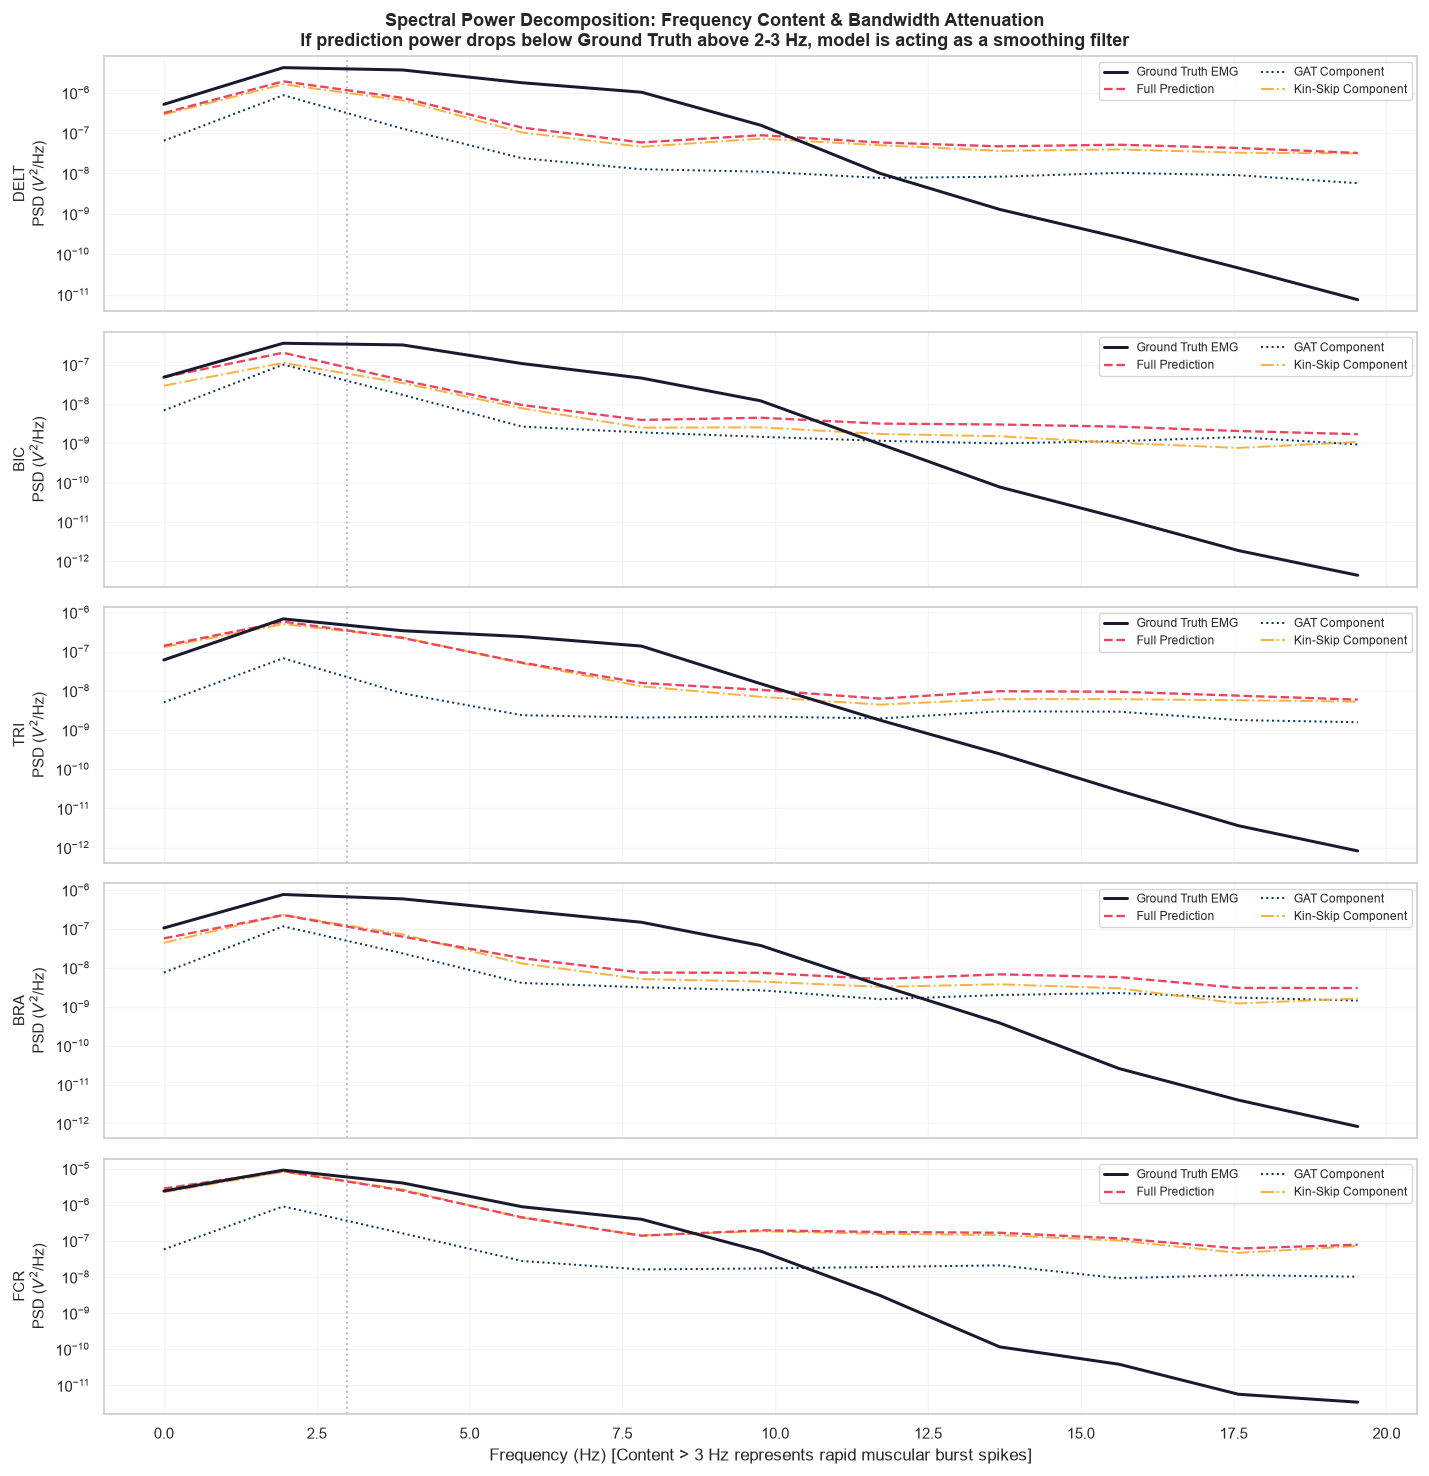


Generating Plot 3: Kinematic State Separation Density Grid...
Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\kinematic_velocity_acceleration_density.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\kinematic_velocity_acceleration_density.pdf


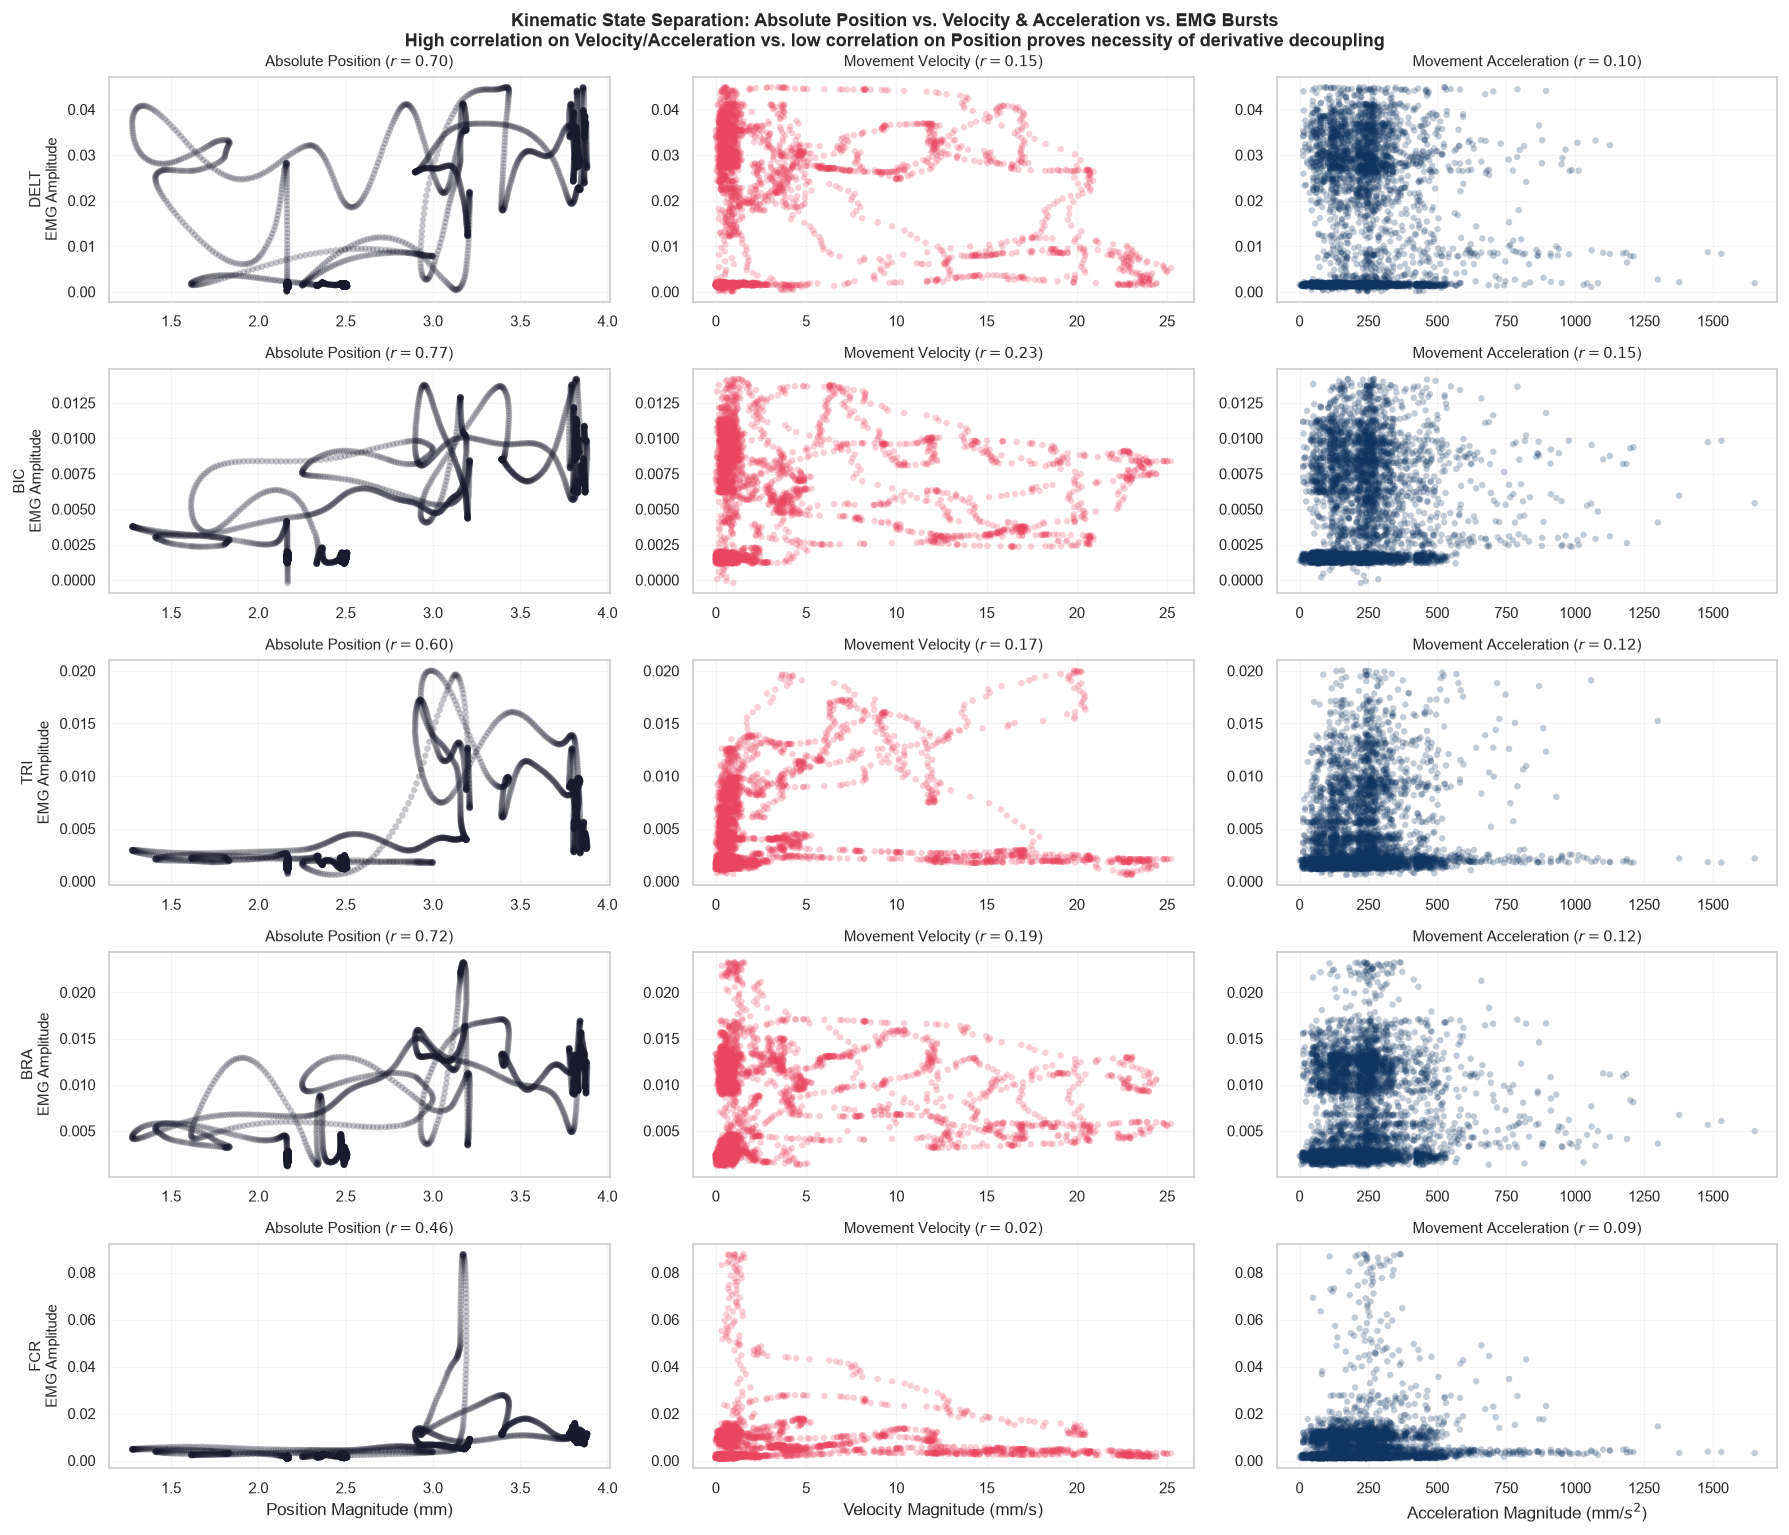

In [43]:
# ── DIAGNOSTIC: Latency Lag, Spectral Power Decomposition & Kinematic Velocity Density
from main.plots import (
    plot_neural_mechanical_latency_lag,
    plot_spectral_power_decomposition,
    plot_kinematic_velocity_acceleration_density,
)

best_model.eval()

# ── PLOT 1: Neural-Mechanical Latency Lag ──
print("Generating Plot 1: Neural-Mechanical Latency Lag Analysis...")
fig_lat = plot_neural_mechanical_latency_lag(
    model=best_model,
    eeg_window=eeg_b,
    kin_window=kin_b,
    emg_target=true_np,
    emg_names=EMG_NAMES,
    fs=500,
    max_lag_ms=250,
    emg_mean=emg_mean,
    emg_std=emg_std,
    cfg=notebook_cfg
)
plt.show()

# ── PLOT 2: Spectral Power Decomposition ──
print("\nGenerating Plot 2: Spectral Power Decomposition (Welch's PSD)...")
fig_spec = plot_spectral_power_decomposition(
    model=best_model,
    eeg_window=eeg_b,
    kin_window=kin_b,
    emg_target=true_np,
    emg_names=EMG_NAMES,
    fs=500,
    max_freq_hz=20.0,
    emg_mean=emg_mean,
    emg_std=emg_std,
    cfg=notebook_cfg
)
plt.show()

# ── PLOT 3: Kinematic Velocity & Acceleration Density Alignment ──
print("\nGenerating Plot 3: Kinematic State Separation Density Grid...")
fig_kin_dens = plot_kinematic_velocity_acceleration_density(
    kin_window=kin_b,
    emg_target=true_np,
    emg_names=EMG_NAMES,
    fs=500,
    cfg=notebook_cfg
)
plt.show()

In [44]:
# ============================================================================
# [LOSOCV ONLY] Advance to the next fold
# ============================================================================
# When running LOSOCV manually fold-by-fold, run this cell to advance to the next
# held-out subject, then re-run cells 7 through 19 to train & evaluate that fold.
# ─────────────────────────────────────────────────────────────────────────────
if is_losocv:
    _current_idx = participant_list.index(p_test)
    _next_idx = _current_idx + 1
    if _next_idx < len(participant_list):
        p_test = participant_list[_next_idx]
        _train_candidates = [p for p in participant_list if p != p_test]
        val_participant    = _train_candidates[-1]
        train_participants = _train_candidates[:-1]
        test_participants  = [p_test]
        subject_str = f"LOSO_P{p_test}"
        print(f"Advanced to fold {_next_idx + 1}/{len(participant_list)}: Test = P{p_test}")
        print(f"  Train participants : {train_participants}")
        print(f"  Val participant    : [{val_participant}]")
    else:
        print("All LOSOCV folds completed!")
else:
    print("Not in LOSOCV mode — this cell is a no-op.")

Not in LOSOCV mode — this cell is a no-op.
